In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import numba
import seaborn as sns
import random
import scipy

sc.set_figure_params(dpi=80)

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
copy_number_inference = lazy_import("copy_number_inference",os.path.join(utils_dir, "copy_number_inference.py"))
gene_signatures_utils = lazy_import("gene_signatures_utils",os.path.join(utils_dir, "gene_signatures.py"))

from general_utils import ismember, grep
from plotting_functions import plot_individual_category, plot_scatter, plot_signature, plot_gene, get_pseudo_colors
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups
from thresholding_functions import threshold_otsu, threshold_triangle
from copy_number_inference import plot_CNV_matrix
from gene_signatures_utils import toupper, attach_selected_signatures


Set figure parameters

In [ ]:
experiment_code = "KPLOH"
figure_path = os.path.join('Figures', experiment_code)
os.makedirs(figure_path, exist_ok=True)
sc.settings.figdir = figure_path

SAVE_FIGURES = False
if SAVE_FIGURES:
    sc.set_figure_params(dpi=300)
else:
    sc.set_figure_params(dpi=80)

### Import data

In [ ]:
adata = sc.read_h5ad("../data/Reyes_KPLOH_SUBSET_pretumor_PDAC__integrated.h5ad")

### Make basic plot with labeled cell states

(np.float64(-114552.67905036714),
 np.float64(134421.434295672),
 np.float64(-77584.41358049665),
 np.float64(129943.55080701428))

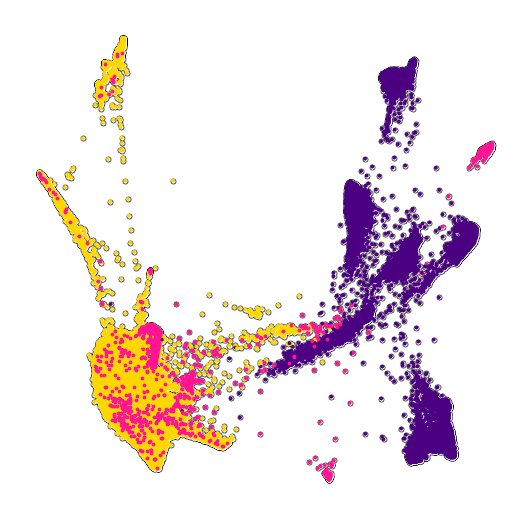

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

unique_conditions = np.unique(adata.obs['condition'])
condition_colors = ['deeppink', 'gold', 'deeppink', 'indigo', 'indigo', 'indigo']
colors = np.array([condition_colors[x] for x in ismember(adata.obs['condition'], unique_conditions)[0]])

subcells = ismember(adata.obs['condition'], unique_conditions)[1]
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

subcells = ismember(adata.obs['condition'], ['K4pretumorSP'])[1]
my_scatter = plt.scatter(x[subcells], y[subcells], s=point_size, color='deeppink')

plt.grid(False)
plt.axis(False)

Simplify condition and sample_id annotations

In [ ]:
condition_simple = adata.obs['condition'].to_numpy()
condition_simple[condition_simple == 'K4microtumorSP'] = 'K4pretumorSP'
condition_simple[condition_simple == 'K5ctrl'] = 'K5tumorSP'
condition_simple[condition_simple == 'K6ctrl'] = 'K5tumorSP'
adata.obs['condition_simple'] = condition_simple.copy()

adata.obs['sample_id'] = [re.sub('_[^_]*$', '', x) for x in adata.obs['replicate_id']]
adata.obs['sample_id'] = [re.sub('.*Spontaneous_', '', x) for x in adata.obs['sample_id']]
adata.obs['sample_id'] = [re.sub('\.\d$', '', x) for x in adata.obs['sample_id']]
adata.obs['sample_id'] = [x.capitalize() for x in adata.obs['sample_id']]
adata.obs['sample_id'] = [re.sub('_', ' ', x) for x in adata.obs['sample_id']]
sample_id_simple = adata.obs['sample_id'].to_numpy()
sample_id_simple = [re.sub('microtumor', 'pretumor', x) for x in sample_id_simple]
sample_id_simple = [re.sub('Met', 'Tumor', x) for x in sample_id_simple] # Used only for plotting
adata.obs['sample_id_simple'] = sample_id_simple.copy()

Highlight individual samples in force-directed layout for supplementary material

In [ ]:
sample_colors = {
    'Pre-tumor p53 proficient 0':'#D6C99D',
    'Pre-tumor p53 proficient 1':'#F3C5DC',
    'Pre-tumor p53 proficient 2':'#C4DF99',
    'Pre-tumor p53 proficient 3':'#F7B494',
    'Pre-tumor p53 proficient 4':'#A3CFE4',
    'Pre-tumor p53 proficient 5':'#FDC577',
    'Pre-tumor p53 deficient 1':'#DA4699',
    'Pre-tumor p53 deficient 2':'#5CB647',
    'Pre-tumor p53 deficient 4':'#0085BE',
    'Pre-tumor p53 deficient 5':'#EB7723',
    'Tumor p53 deficient 1':'#48A9BF',
    'Tumor p53 deficient 2':'#F0D335',
    'Tumor p53 deficient 3':'#EF4023',
    'Tumor p53 deficient 4':'#008973',
    'Tumor p53 deficient 5':'#46375C',
    'Tumor p53 deficient 6':'#EB9922'
}

sample_colors = {
    'Pre-tumor p53 proficient 0':'#EB7723',
    'Pre-tumor p53 proficient 1':'#DA4699',
    'Pre-tumor p53 proficient 2':'#5CB647',
    'Pre-tumor p53 proficient 3':'#7254A3',
    'Pre-tumor p53 proficient 4':'#0085BE',
    'Pre-tumor p53 proficient 5':'#FBDA0B',
    'Pre-tumor p53 deficient 1':'#DA4699',
    'Pre-tumor p53 deficient 2':'#5CB647',
    'Pre-tumor p53 deficient 4':'#0085BE',
    'Pre-tumor p53 deficient 5':'#FBDA0B',
    'Tumor p53 deficient 1':'#48A9BF',
    'Tumor p53 deficient 2':'#F0D335',
    'Tumor p53 deficient 3':'#EF4023',
    'Tumor p53 deficient 4':'#008973',
    'Tumor p53 deficient 5':'#46375C',
    'Tumor p53 deficient 6':'#EB9922'
}


(np.float64(-114552.67905036714),
 np.float64(134421.434295672),
 np.float64(-77584.41358049665),
 np.float64(129943.55080701428))

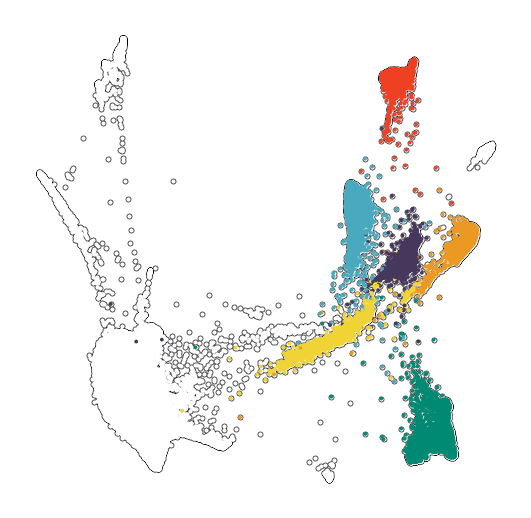

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K5tumorSP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

(np.float64(-114552.67905036714),
 np.float64(134421.434295672),
 np.float64(-77584.41358049665),
 np.float64(129943.55080701428))

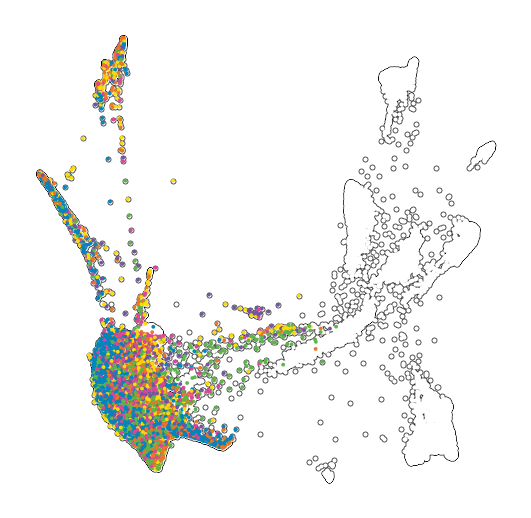

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K4pretumorDP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

(np.float64(-114552.67905036714),
 np.float64(134421.434295672),
 np.float64(-77584.41358049665),
 np.float64(129943.55080701428))

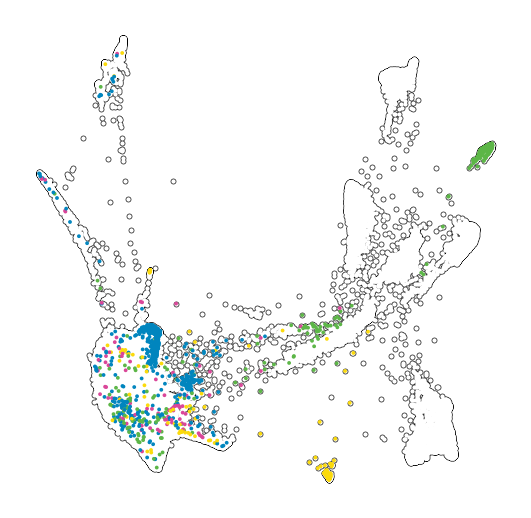

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K4pretumorSP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

In [ ]:
adata.obs['sample_id_simple'].value_counts(sort=False)

sample_id_simple
Pre-tumor p53 deficient 2      558
Pre-tumor p53 deficient 1       88
Pre-tumor p53 proficient 1    3365
Pre-tumor p53 proficient 3    1503
Pre-tumor p53 proficient 0    2585
Pre-tumor p53 proficient 2    3194
Pre-tumor p53 deficient 4      614
Pre-tumor p53 proficient 4    6299
Pre-tumor p53 deficient 5      212
Pre-tumor p53 proficient 5    2076
Tumor p53 deficient 6         2036
Tumor p53 deficient 3         2600
Tumor p53 deficient 2         2791
Tumor p53 deficient 5         2295
Tumor p53 deficient 1         2869
Tumor p53 deficient 4         3467
Name: count, dtype: int64

Plot pseudocolored gene expression for fluorescent proteins for supplementary material

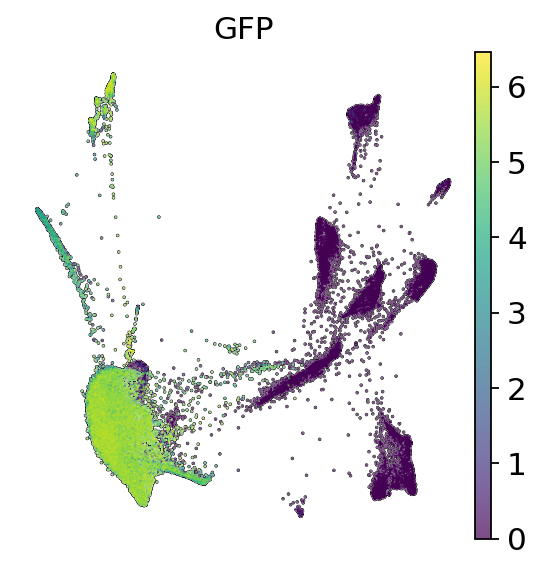

In [ ]:
if SAVE_FIGURES:
    sc.pl.draw_graph(adata, color='GFP', layout='fa', frameon=False, add_outline=True, save='Figure20231113_GFP_expression.pdf')
else:
    sc.pl.draw_graph(adata, color='GFP', layout='fa', frameon=False, add_outline=True)

### Load CNV inference results and make a plot to identify cells that have quiet vs rearranged genomes

In [ ]:
adata_cnv = sc.read_h5ad('../data/Reyes_KPLOH_SUBSET_all__CNV.h5ad')

Remove suffix from single cell name

In [ ]:
adata_cnv.obs_names = [re.sub('-\d+-\d+', '', x) for x in adata_cnv.obs_names]
adata.obs_names = [re.sub('-\d+-\d+', '', x) for x in adata.obs_names]

Identify which cells in CNV dataset are also present in current dataset

In [ ]:
adata_cnv = adata_cnv[ismember(adata_cnv.obs_names, adata.obs_names)[1],:].copy()
adata_cnv = adata_cnv[np.argsort(adata_cnv.obs['prefix'], kind='mergesort'),:].copy()

Classify SP cells according to loss of chr11

In [ ]:
chr11_mean = adata_cnv.obsm['smoothed_counts'][:,adata_cnv.uns['newAnnotation']['chrNum']==11].mean(axis=1)
chr11_loss = chr11_mean < -0.2
adata_cnv.obs['chr11_mean'] = chr11_mean.copy()
adata_cnv.obs['chr11_loss'] = chr11_loss.copy()

karyotype_class = adata_cnv.obs['karyotype_class'].to_numpy()
karyotype_class[np.logical_and(karyotype_class == '3_pre_sp_quiet', chr11_loss == False)] = '5_pre_sp_noChr11Loss'
adata_cnv.obs['karyotype_class_2'] = karyotype_class.copy()
adata_cnv.obs['Gfp'] = get_gene(adata_cnv, 'GFP')

In [ ]:
adata_cnv.obs['karyotype_class_2'].value_counts()

karyotype_class_2
6_tumor_sp              16058
1_pre_dp_diploid         9822
2_pre_dp_chr6_gain       9200
4_pre_sp_rearranged       688
5_pre_sp_noChr11Loss      495
3_pre_sp_quiet            289
Name: count, dtype: int64

Simplify sample ids for CNV anndata object

In [ ]:
adata_cnv.obs['sample_id'] = [re.sub('_[^_]*$', '', x) for x in adata_cnv.obs['replicate_id']]
adata_cnv.obs['sample_id'] = [re.sub('.*Spontaneous_', '', x) for x in adata_cnv.obs['sample_id']]
adata_cnv.obs['sample_id'] = [re.sub('\.\d$', '', x) for x in adata_cnv.obs['sample_id']]
adata_cnv.obs['sample_id'] = [x.capitalize() for x in adata_cnv.obs['sample_id']]
adata_cnv.obs['sample_id'] = [re.sub('_', ' ', x) for x in adata_cnv.obs['sample_id']]
sample_id_simple = adata_cnv.obs['sample_id'].to_numpy()
sample_id_simple = [re.sub('microtumor', 'pretumor', x) for x in sample_id_simple]
sample_id_simple = [re.sub('Met', 'Tumor', x) for x in sample_id_simple] # Used only for plotting
adata_cnv.obs['sample_id_simple'] = sample_id_simple.copy()

ordering = np.argsort(adata_cnv.obs['sample_id_simple'], kind = 'mergesort')
adata_cnv = adata_cnv[ordering,:].copy()

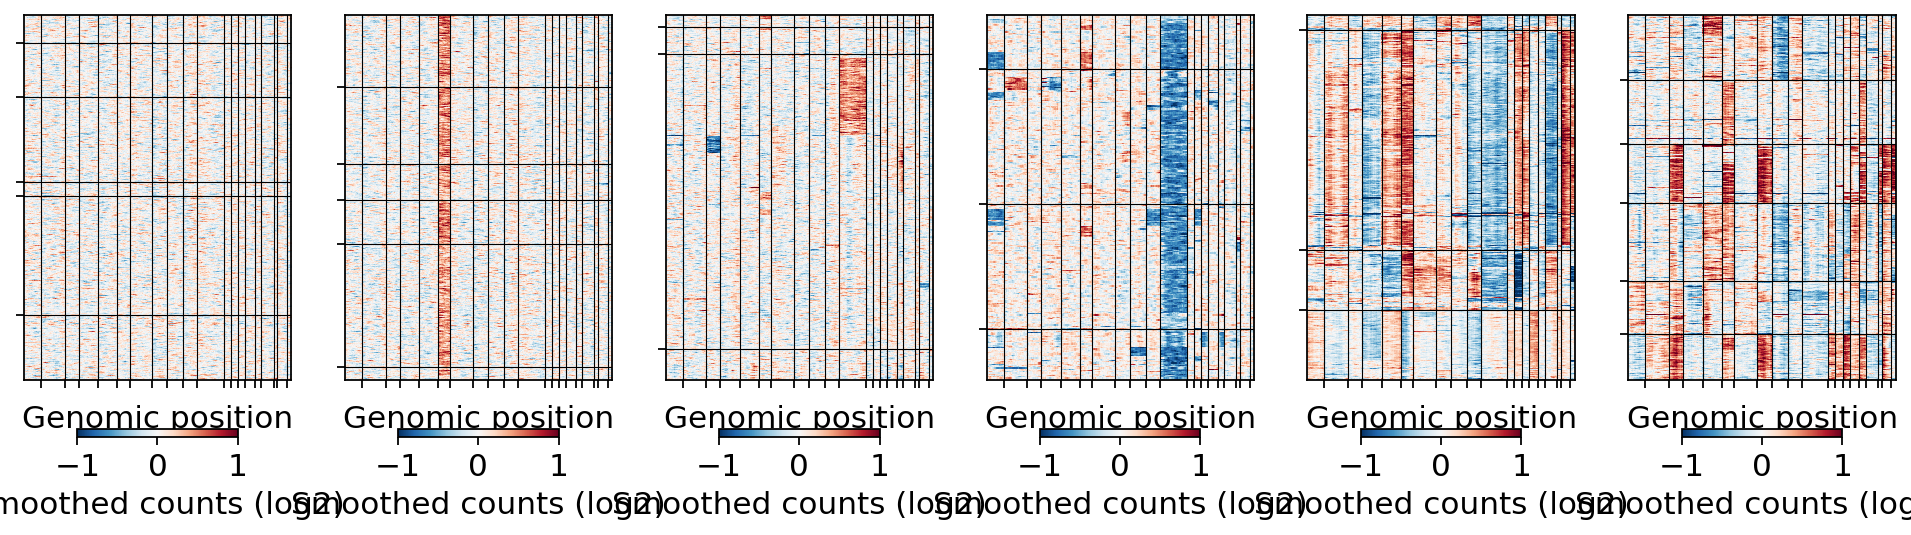

In [ ]:
f, ax = plt.subplots(1,6, figsize=[15,4])
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), ismember(adata_cnv.obs['karyotype_class_2'], ['1_pre_dp_diploid'])[1], ax[0])
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), ismember(adata_cnv.obs['karyotype_class_2'], ['2_pre_dp_chr6_gain'])[1], ax[1])
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), adata_cnv.obs['karyotype_class_2'] == '5_pre_sp_noChr11Loss', ax[2])
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), adata_cnv.obs['karyotype_class_2'] == '3_pre_sp_quiet', ax[3])
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), adata_cnv.obs['karyotype_class_2'] == '4_pre_sp_rearranged', ax[4])
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['sample_id_simple'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), adata_cnv.obs['karyotype_class_2'] == '6_tumor_sp', ax[5])

if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Figure20231105_copy_number_all_classes.pdf'))

Realign CNV object to match ids in main anndata. The goal is to transfer karyotype annotations to main anndata

In [ ]:
adata_cnv_sub = adata_cnv[adata.obs_names,:].copy()
adata.obs['karyotype_class'] = adata_cnv_sub.obs['karyotype_class_2'].copy()

I found that a small subset of cells had chr11 loss, but were sorted as part of GFP+ cells. I re-classified these are p53 deficient, with rearranged genomes to be the most accurate. I kept the updated replicate id in a different annotation so that there is not a confusion downstream regarding the file of origin of these particular cells.

I also found that a small subset of cells classified as GFP negative had GFP expression and lacked chr11 loss. However, I decided to keep them annotated as p53 deficient because I have evidence that GFP can be lost without chr11 loss.

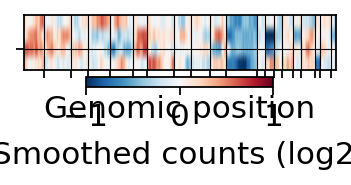

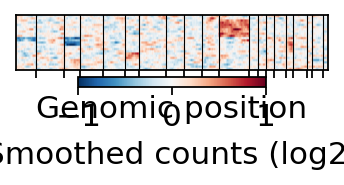

In [ ]:
chr11_loss = adata_cnv.obs['chr11_loss']

f, ax = plt.subplots(1,1, figsize=[2.5,0.6])
SP_contaminants = np.logical_and(np.logical_and(adata_cnv.obs['condition'] == 'K4pretumorDP', adata_cnv.obs['Gfp'] < 2), chr11_loss)
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), SP_contaminants, ax)

f, ax = plt.subplots(1,1, figsize=[2.5,0.6])
DP_contaminants = np.logical_and(np.logical_and(adata_cnv.obs['condition'] == 'K4pretumorSP', adata_cnv.obs['Gfp'] >= 5), np.logical_not(chr11_loss))
plot_CNV_matrix(adata_cnv.obsm['smoothed_counts'], adata_cnv.obs['prefix'], adata_cnv.uns['newAnnotation']['chrNum'].to_numpy(), DP_contaminants, ax)

modified_ids = np.array(ismember(adata.obs_names, adata_cnv.obs_names[SP_contaminants])[1])

In [ ]:
np.sum(modified_ids)

np.int64(4)

In [ ]:
adata.obs['replicate_id_original'] = adata.obs['replicate_id'].copy()

condition = adata.obs['condition'].to_numpy()
condition[modified_ids] = 'K4pretumorSP'
adata.obs['condition'] = condition.copy()

karyotype_class = adata.obs['karyotype_class'].to_numpy()
karyotype_class[modified_ids] = '4_pre_sp_rearranged'
adata.obs['karyotype_class'] = karyotype_class.copy()

genotype = adata.obs['genotype'].to_numpy()
genotype[modified_ids] = 'p53_deficient'
adata.obs['genotype'] = genotype.copy()

replicate_id = adata.obs['replicate_id'].to_numpy()
replicate_id[modified_ids] = [re.sub('proficient', 'deficient', x) for x in replicate_id[modified_ids]]
replicate_id[modified_ids] = [re.sub('DP', 'SP', x) for x in replicate_id[modified_ids]]
adata.obs['replicate_id'] = replicate_id.copy()


Record for manuscript

In [ ]:
df = adata.obs[['sample_id_simple', 'prefix', 'replicate_number', 'condition', 'hash_id', 'batch', 'genotype']]
df['sample_id_simple'] = df['sample_id_simple'].cat.remove_unused_categories()
df['prefix'] = df['prefix'].cat.remove_unused_categories()
df['hash_id'] = df['hash_id'].cat.remove_unused_categories()

freq = df.groupby(['sample_id_simple', 'prefix', 'condition', 'hash_id', 'batch']).agg('count').reset_index().drop_duplicates()
freq = freq.loc[freq['genotype'] > 0,:]
freq

/tmp/ipykernel_3698020/2394706304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sample_id_simple'] = df['sample_id_simple'].cat.remove_unused_categories()
/tmp/ipykernel_3698020/2394706304.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prefix'] = df['prefix'].cat.remove_unused_categories()
/tmp/ipykernel_3698020/2394706304.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

,sample_id_simple,prefix,condition,hash_id,batch,replicate_number,genotype
333,Pre-tumor p53 deficient 1,254_2RH_PanINPM_Kate_CD45_1_31,K4pretumorSP,unhashed,2,88,88
2317,Pre-tumor p53 deficient 2,254_RH_PanINPM_Kate_CD45_1_4,K4microtumorSP,unhashed,2,404,404
2349,Pre-tumor p53 deficient 2,254_RH_PanINPM_Kate_CD45_1_4,K4pretumorSP,unhashed,2,154,154
5218,Pre-tumor p53 deficient 4,Preclinical_SP_batch1,K4pretumorSP,A0301,7,10,10
5222,Pre-tumor p53 deficient 4,Preclinical_SP_batch1,K4pretumorSP,A0302,7,590,590
5226,Pre-tumor p53 deficient 4,Preclinical_SP_batch1,K4pretumorSP,undefined,7,14,14
7215,Pre-tumor p53 deficient 5,pre_sp_2,K4microtumorSP,unhashed,8,129,129
7247,Pre-tumor p53 deficient 5,pre_sp_2,K4pretumorSP,unhashed,8,83,83
7421,Pre-tumor p53 proficient 0,53_NH_PanINPM_GFPh,K4pretumorDP,unhashed,2,2585,2585
9341,Pre-tumor p53 proficient 1,254_2RH_PanINPM_GFPh,K4pretumorDP,unhashed,2,3365,3365


(np.float64(-114552.67905036714),
 np.float64(134421.434295672),
 np.float64(-77584.41358049665),
 np.float64(129943.55080701428))

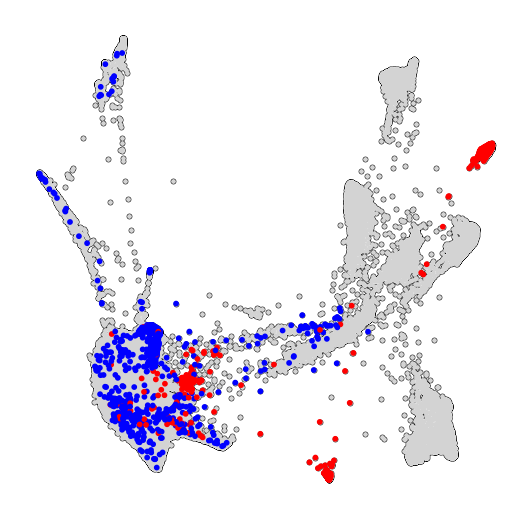

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color='lightgray')

unique_conditions = np.unique(adata.obs['karyotype_class'])
condition_colors = ['yellow', 'red', 'blue', 'red', 'blue', 'purple']
colors = np.array([condition_colors[x] for x in ismember(adata.obs['karyotype_class'], unique_conditions)[0]])

subcells = ismember(adata.obs['karyotype_class'], ['3_pre_sp_quiet','4_pre_sp_rearranged', '5_pre_sp_noChr11Loss'])[1]
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)



### Compute and plot transcriptional signatures from Burdziak, Alonso-Curbelo et al.

In [ ]:
selected_reference = adata.obs['condition'] == 'K4pretumorDP'
adata = zscore_with_subset(adata, selected_reference)
adata.layers['zscore'] = adata.layers['zscore_subcells'].copy()

/data1/lowes/reyesj3/miniconda3/envs/rapidsai/lib/python3.11/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'zscore_subcells' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


In [ ]:
selected_signatures = [
    'ADM_specific_0', 'gastric_specific_0', 'mitotic_specific_0', 'neuroendocrine_specific_0', 
    'progenitor_specific_0', 'tuft_specific_30', 'BiegingRolett_p53_TSAG_bound', 'David_Smad4_dependent_tgfb_response',
    'FisherOncogeneTable2_processed', 'Vallejo_KRAS_8genes', 'Glycolysis_Warburg', 'DAC_Kras_vs_ADM_UP_T3_vs_T2',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'LOH_single_cell_pseudobulk_UP_in_PDAC', 'TASDEMIR_Senescence_UP',
    'SENESCENCE_INTERNAL_PDAC_p53_restoration_UpSet_UP_Top', 'p53_canonical', 'cdkn2a_canonical'
]
attach_selected_signatures(adata, '../signatures/', selected_signatures)

100%|██████████| 18/18 [00:01<00:00, 17.53it/s]


Plot cell state signatures in p53 proficient and deficient pre-tumor stage cells

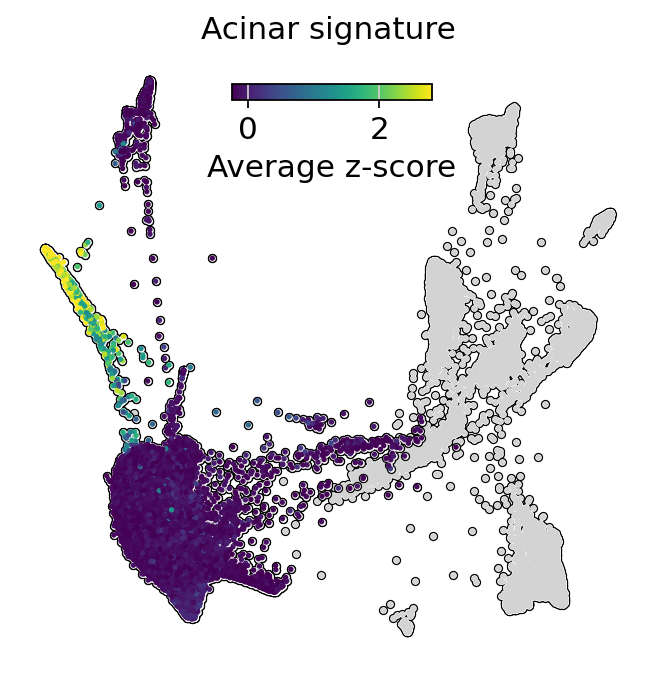

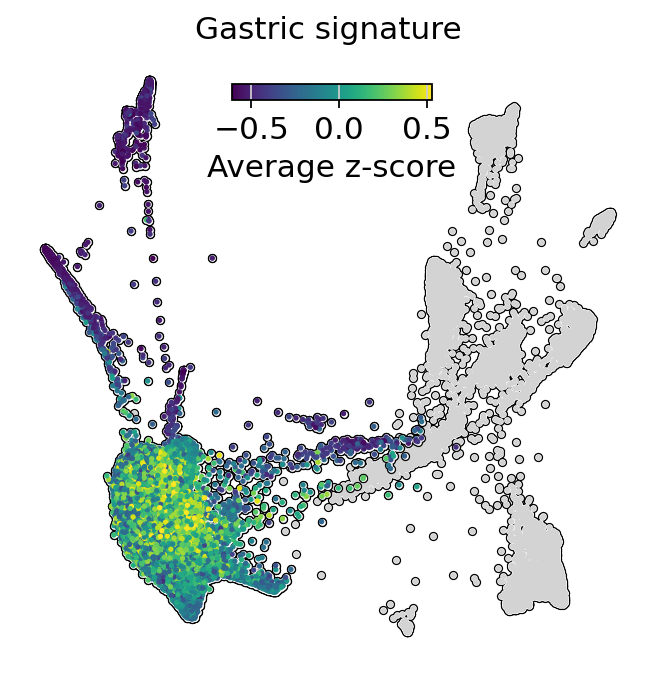

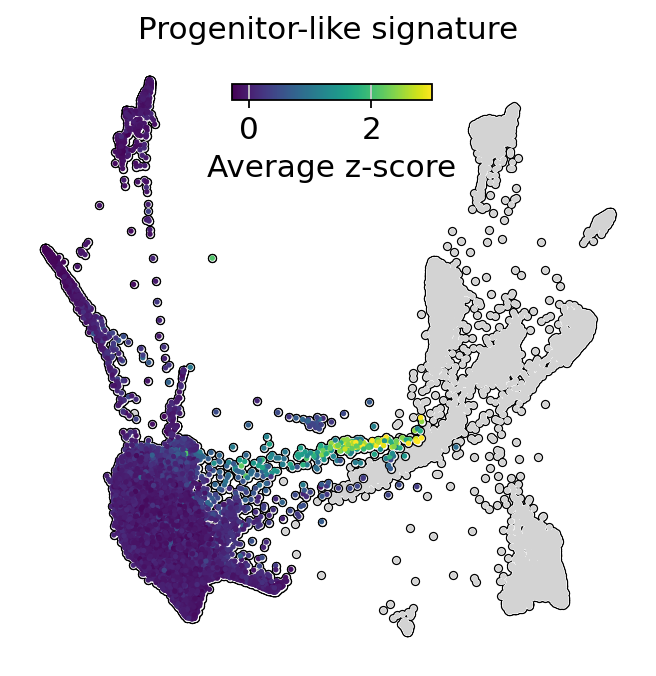

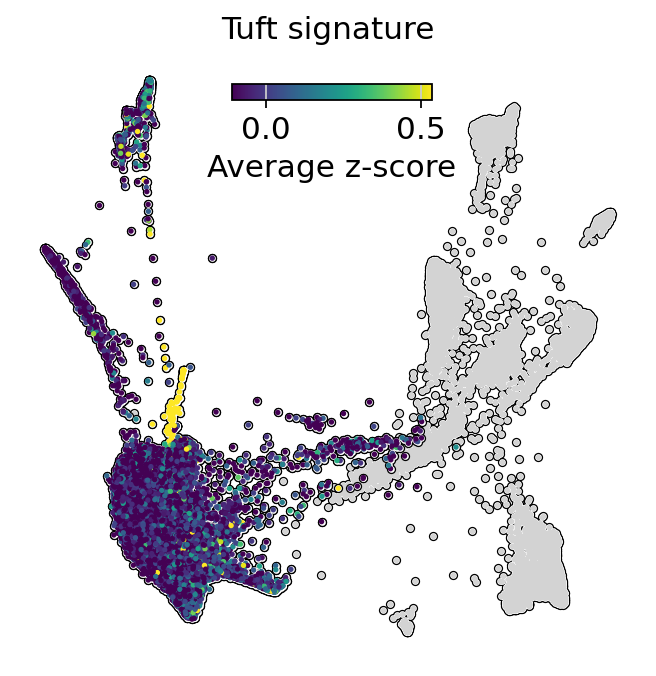

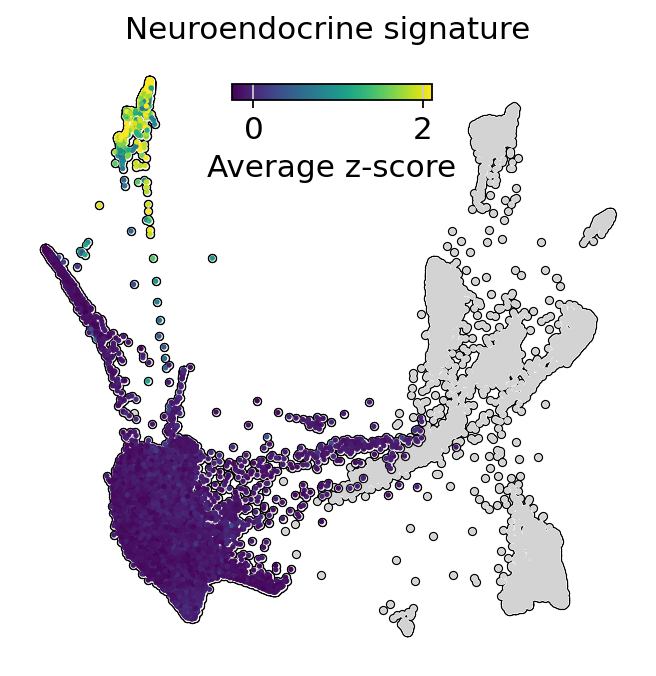

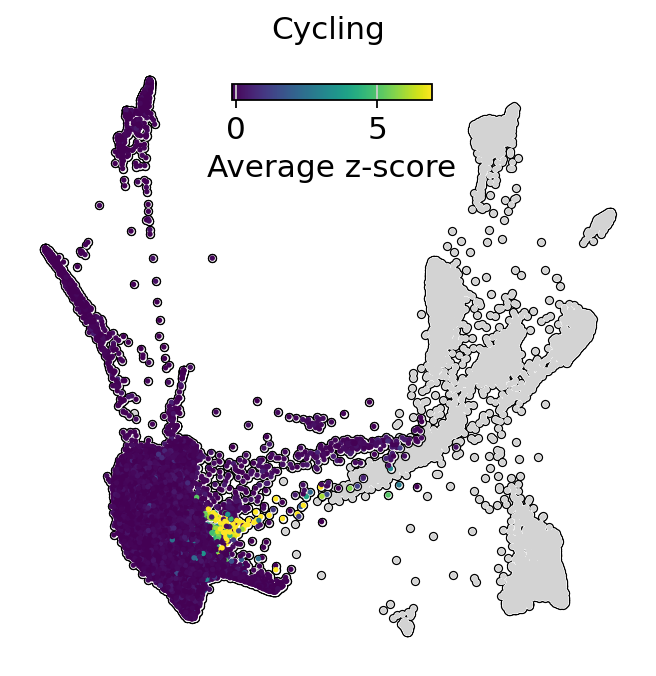

In [ ]:
suffix = '_specific_0'

grayout_cells = ismember(adata.obs['condition'], ['K4microtumorSP', 'K5ctrl','K5tumorSP', 'K6ctrl'])[1]
ax, cb_ax = plot_signature(adata, 'X_draw_graph_fa', 'ADM' + suffix, grayout_cells = grayout_cells, s=2, figsize=[5,5], grayout_color='lightgray')
ax.set_title('Acinar signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231028_KPLOH_acinar_signature.pdf'))

ax, cb_ax = plot_signature(adata, 'X_draw_graph_fa', 'gastric' + suffix, grayout_cells = grayout_cells, s=2, figsize=[5,5], grayout_color='lightgray')
ax.set_title('Gastric signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231028_KPLOH_gastric_signature.pdf'))

ax, cb_ax = plot_signature(adata, 'X_draw_graph_fa', 'progenitor' + suffix, grayout_cells = grayout_cells, s=2, figsize=[5,5], grayout_color='lightgray')
ax.set_title('Progenitor-like signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231028_KPLOH_progenitor_signature.pdf'))

ax, cb_ax = plot_signature(adata, 'X_draw_graph_fa', 'tuft_specific_30', grayout_cells = grayout_cells, s=2, figsize=[5,5], grayout_color='lightgray')
ax.set_title('Tuft signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231028_KPLOH_tuft_signature.pdf'))

ax, cb_ax = plot_signature(adata, 'X_draw_graph_fa', 'neuroendocrine' + suffix, grayout_cells = grayout_cells, s=2, figsize=[5,5], grayout_color='lightgray')
ax.set_title('Neuroendocrine signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231028_KPLOH_neuroendocrine_signature.pdf'))

ax, cb_ax = plot_signature(adata, 'X_draw_graph_fa', 'mitotic_specific_0', grayout_cells = grayout_cells, s=2, figsize=[5,5], grayout_color='lightgray')
ax.set_title('Cycling')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231028_KPLOH_cycling_signature.pdf'))


Plot merged cell stage signatures in pre-tumor stage, p53 proficient and deficient cells. Colors result from the contribution of multiple signatures on a cell-by-cell basis

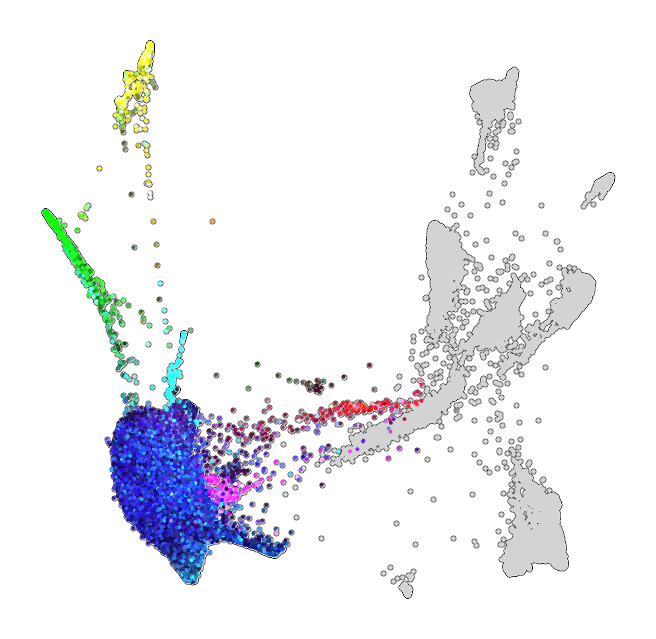

In [ ]:
point_size = 0.5

selected_signatures = [
    'ADM_specific_0', 'progenitor_specific_0', 'gastric_specific_0', 
    'neuroendocrine_specific_0', 'tuft_specific_30', 'mitotic_specific_0'
]
selected_colors = [[0,1,0], [1,0,0], [0,0,1], [1,1,0], [0,1,1], [1,0,1]]

Pseudo_colors = get_pseudo_colors(adata, selected_signatures, selected_colors, quantile_threshold=[0, 0.99])

fig,ax=plt.subplots(1,1,figsize=(5,5))

point_order = np.array(random.sample(list(range(adata.n_obs)), k=adata.n_obs))
ax.scatter(adata.obsm['X_draw_graph_fa'][:,0][point_order], adata.obsm['X_draw_graph_fa'][:,1][point_order], s=point_size*5, color='black', rasterized=True)
ax.scatter(adata.obsm['X_draw_graph_fa'][:,0][point_order], adata.obsm['X_draw_graph_fa'][:,1][point_order], s=point_size*2, color='white', rasterized=True)

ax.scatter(adata.obsm['X_draw_graph_fa'][:,0][point_order],
           adata.obsm['X_draw_graph_fa'][:,1][point_order], 
           color='lightgray',s=point_size, rasterized=True)
subcells = np.array(ismember(adata.obs['condition'], ['K4pretumorDP', 'K4pretumorSP'])[1])
adata.obs['premalignant_like'] = pd.Categorical(subcells)
ax.scatter(adata.obsm['X_draw_graph_fa'][subcells,0],
           adata.obsm['X_draw_graph_fa'][subcells,1],
           c=Pseudo_colors[subcells,:],s=point_size, rasterized=True)
ax.set_axis_off()

df = adata.obs[selected_signatures + ['condition', 'replicate_id']].copy()
df['x'] = adata.obsm['X_draw_graph_fa'][:,0]
df['y'] = adata.obsm['X_draw_graph_fa'][:,0]
df['included'] = subcells

if SAVE_FIGURES:
    df.to_csv(os.path.join(figure_path, 'Figure20231105_transcriptional_signatures_premalignant_DP_SP.csv'))
    plt.savefig(os.path.join(figure_path, 'Figure20231105_transcriptional_signatures_premalignant_DP_SP.pdf'))

### Label clusters by signature

First, identify clusters of cells that correspond to cancer-like or premalignant-like signatures. These are defined as clusters that are enriched for tumor or microtumor samples. These classifications will also aid the identification of cells derived from cancer samples that cluster alongside premalignant cells. Most of these were removed during cleaning, but a few remain here.

In [ ]:
adata.obs['pheno_10'] = pd.Categorical(adata.obs['pheno_10'])
adata.obs['pheno_30'] = pd.Categorical(adata.obs['pheno_30'])

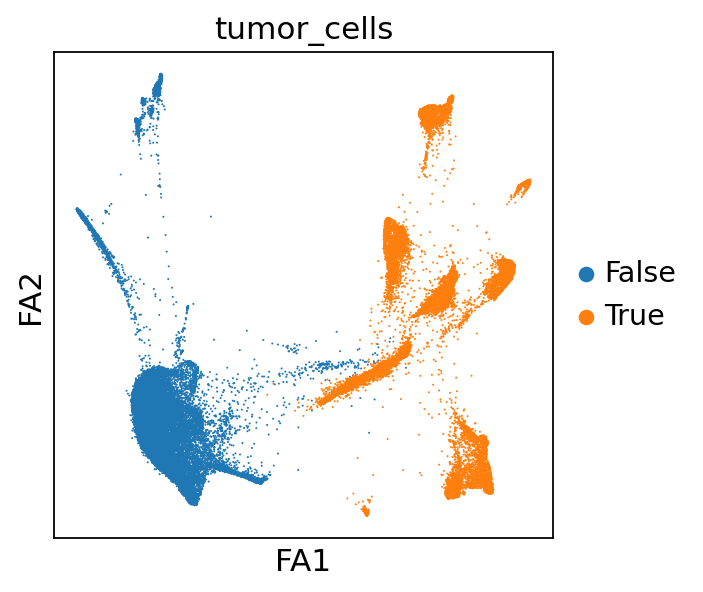

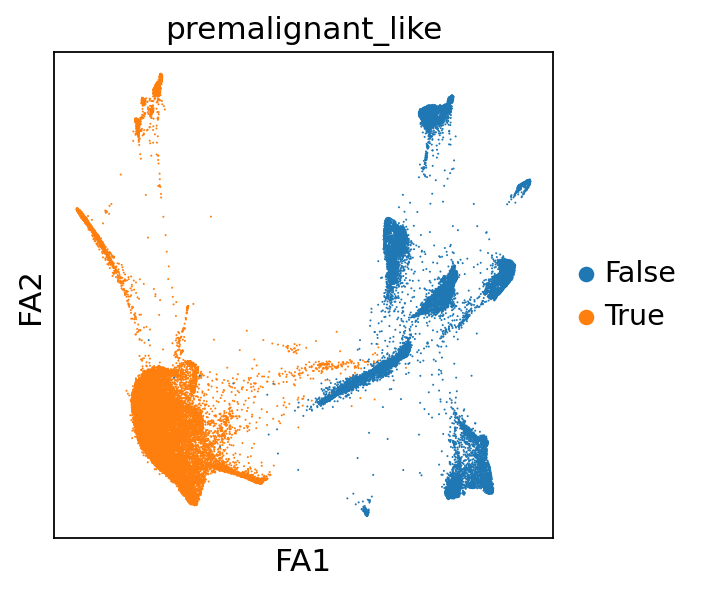

In [ ]:
adata.obs['tumor_cluster'] = pd.Categorical(ismember(adata.obs['pheno_30'], [3,4,5,6,7,8,10,13,15,16,17,18,22,24,27,28,29])[1])
adata.obs['tumor_cells'] = pd.Categorical(np.logical_and(ismember(adata.obs['condition'], ['K4microtumorSP', 'K5tumorSP', 'K5ctrl', 'K6ctrl'])[1], adata.obs['tumor_cluster'] == True))
adata.obs['tumor_samples'] = pd.Categorical(ismember(adata.obs['condition'], ['K4microtumorSP', 'K5tumorSP', 'K5ctrl', 'K6ctrl'])[1])

sc.pl.draw_graph(adata, color='tumor_cells', layout='fa')

subcells = np.array(ismember(adata.obs['condition'], ['K4pretumorDP', 'K4pretumorSP'])[1])
adata.obs['premalignant_like'] = pd.Categorical(subcells)
sc.pl.draw_graph(adata, color='premalignant_like', layout='fa')

Now, I assign cell state identity on the basis of signatures from Burdziak, Alonso-Curbelo et al. and phenograph clusters with k=30. I only annotate pretumor cells based on these signatures

In [ ]:
karyotype_filter = ismember(adata.obs['karyotype_class'], ['1_pre_dp_diploid', '2_pre_dp_chr6_gain', '3_pre_sp_quiet', '4_pre_sp_rearranged', '5_pre_sp_noChr11Loss'])[1]
karyotype_filter = ismember(adata.obs['karyotype_class'], ['1_pre_dp_diploid', '2_pre_dp_chr6_gain', '3_pre_sp_quiet', '5_pre_sp_noChr11Loss'])[1]
condition_filter = ismember(adata.obs['condition'], ['K4pretumorDP', 'K4pretumorSP'])[1]


In [ ]:
adata_sub = adata[ismember(adata.obs['condition'],['K4pretumorDP', 'K4pretumorSP'])[1],:].copy()

Annotate clusters with phenograph k=30

/tmp/ipykernel_3698020/3239316749.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_sub.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')


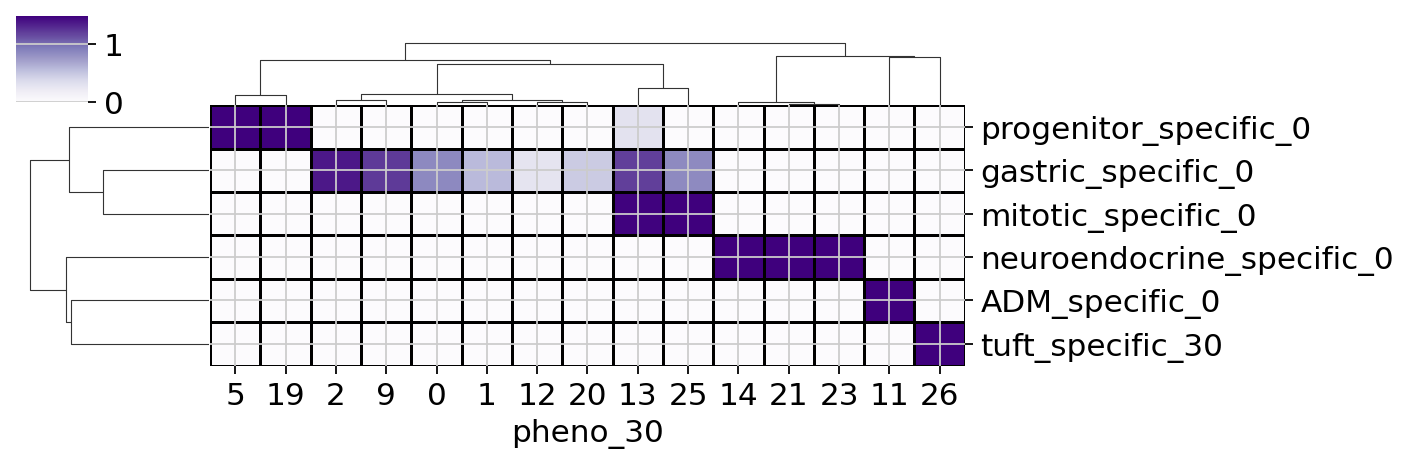

In [ ]:
df = adata_sub.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')
df = df - df.mean(axis=0)
df = df / np.std(df, axis=0)
sns.clustermap(df.T, figsize=[9,3], method='ward', dendrogram_ratio=0.2, cmap='Purples', linewidths = 0.5, vmin=0, vmax=1.5, linecolor='black')
if SAVE_FIGURES:
    df.to_csv(os.path.join(figure_path, "Figure20231112_phenograph_k30_cell_state_signatures.csv"))
    plt.savefig(os.path.join(figure_path, "Figure20231112_phenograph_k30_cell_state_signatures.pdf"), dpi=300)

In [ ]:
cell_type = np.array(["6. Gastric-like"] * adata.n_obs, dtype=object)
cell_type[ismember(adata.obs['pheno_30'], [11])[1]] = '3. ADM'
cell_type[ismember(adata.obs['pheno_30'], [5,19])[1]] = '8. Progenitor-like'
cell_type[ismember(adata.obs['pheno_30'], [2,12,0,1,9,20])[1]] = '6. Gastric-like'
cell_type[ismember(adata.obs['pheno_30'], [14,21,23])[1]] = '1. Neuroendocrine' 
cell_type[ismember(adata.obs['pheno_30'], [26])[1]] = '2. Tuft' ## I assigned cluster 42 to neuroendocrine because it belongs to cluster 26 in coarser clustering
cell_type[ismember(adata.obs['pheno_30'], [13,25])[1]] = '7. Mitotic'
cell_type[ismember(adata.obs['tumor_cells'], [True])[1]] = '9. Tumor'
cell_type[np.logical_and(adata.obs['tumor_samples'] == True, adata.obs['tumor_cells'] == False)] = '9. Tumor_premalignant_like'

adata.obs['cell_type'] = cell_type

Refine progenitor-like annotations using diffusion components using different strategies

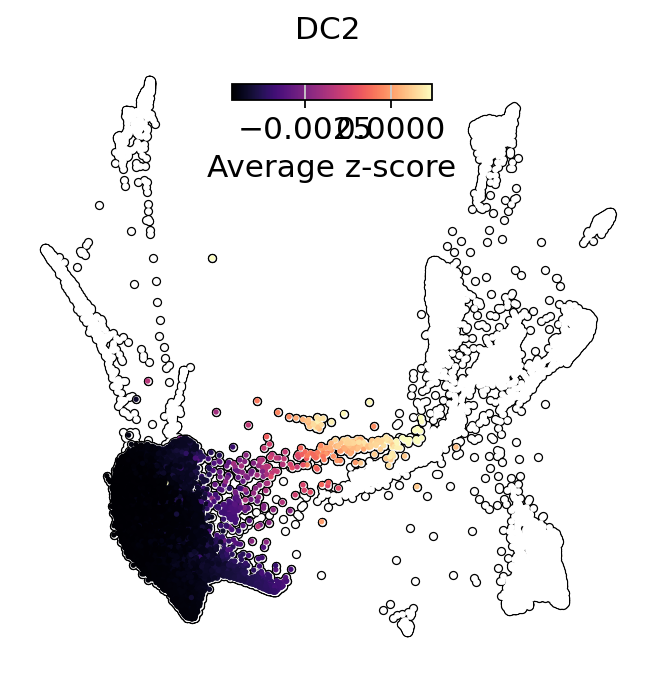

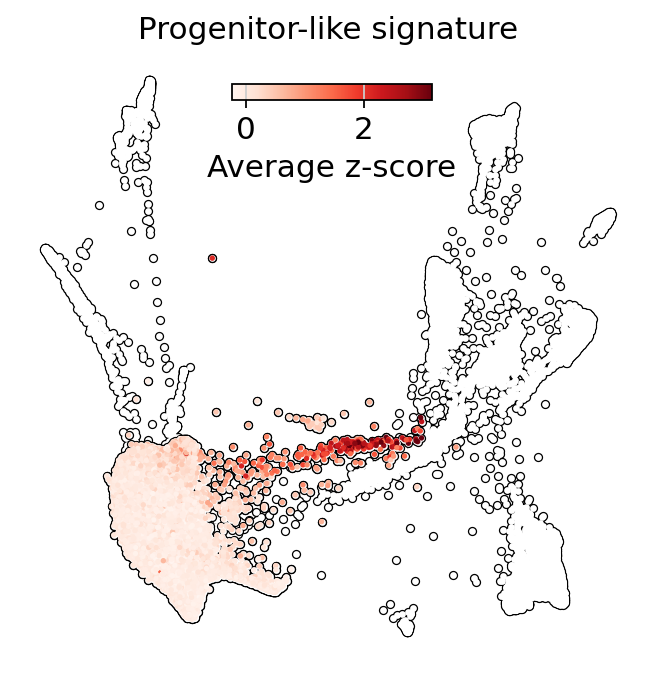

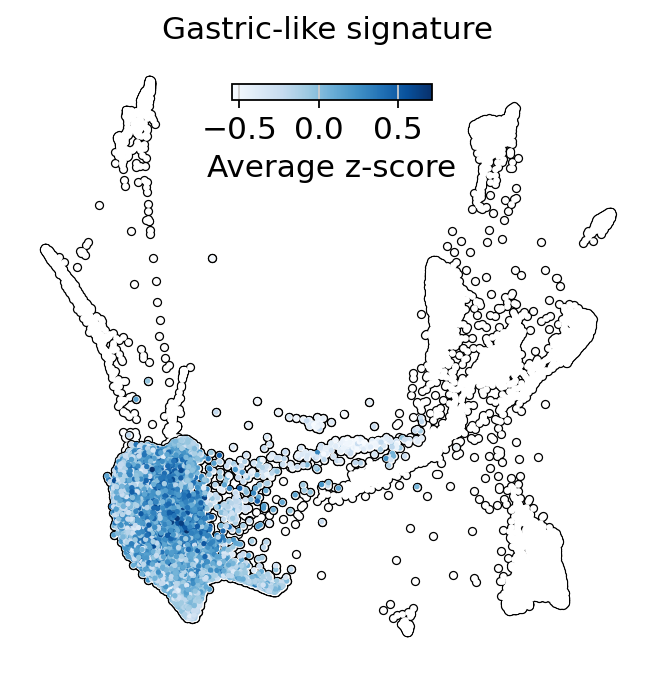

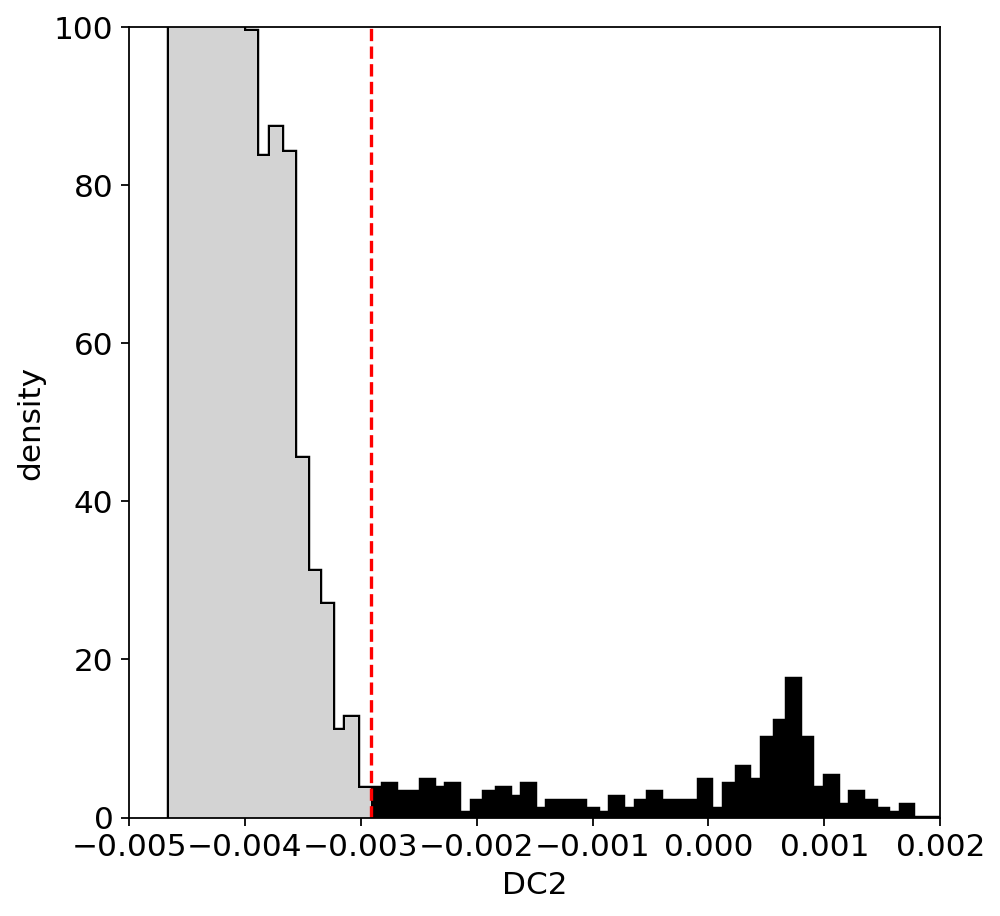

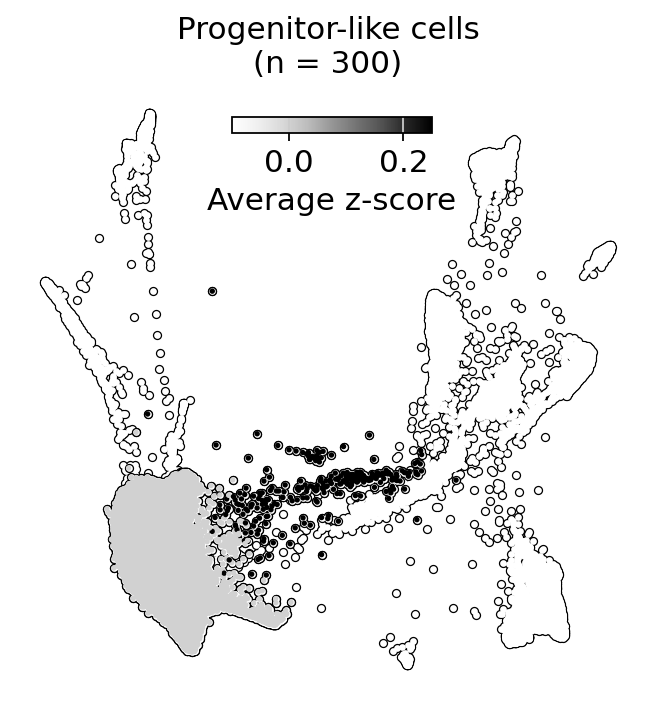

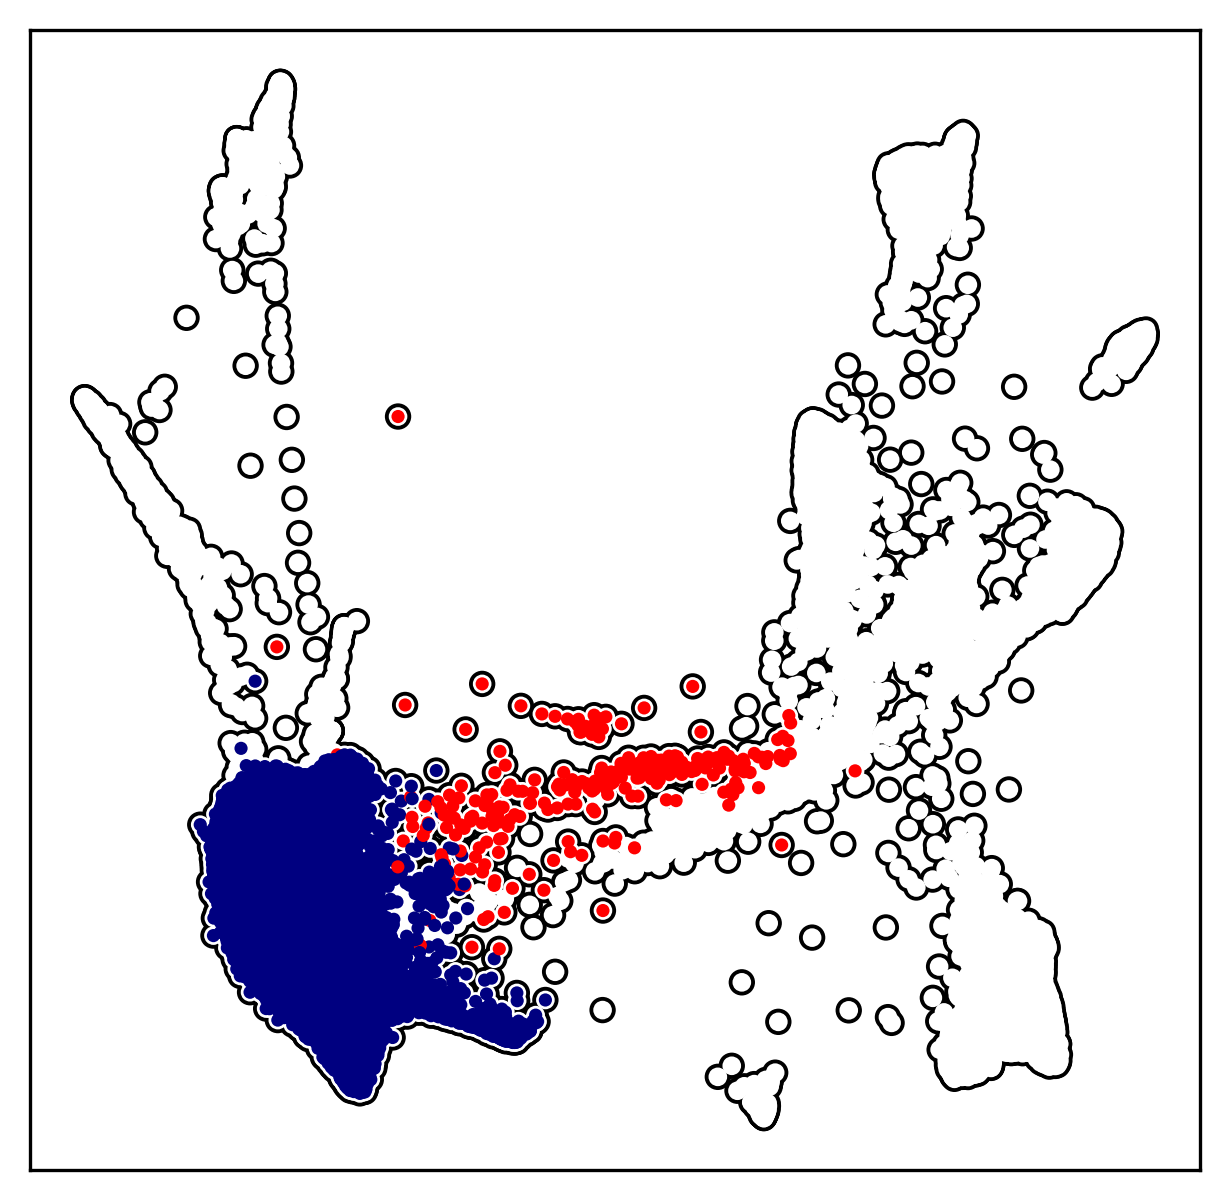

In [ ]:
# Subset adata
subcells = ismember(adata.obs['cell_type'], ['6. Gastric-like', '8. Progenitor-like'])[1]
adata_sub = adata[subcells,:].copy()

# Construct karyotype and condition filters for this subset
karyotype_filter = ismember(adata_sub.obs['karyotype_class'], ['1_pre_dp_diploid', '2_pre_dp_chr6_gain', '3_pre_sp_quiet', '5_pre_sp_noChr11Loss'])[1]
condition_filter = ismember(adata_sub.obs['condition'], ['K4pretumorDP', 'K4pretumorSP'])[1]

# Initialize plotting parameters
xval = adata_sub.obsm['X_draw_graph_fa'][:,0]
yval = adata_sub.obsm['X_draw_graph_fa'][:,1]
cval = -adata_sub.obsm['X_diff_comp'][:,1]
DC_title = "DC2"

# Plot DC2 as signature
adata.obs['DC2'] = -adata.obsm['X_diff_comp'][:,1].copy()
vmin = np.quantile(adata.obs['DC2'][subcells], 0.001)
vmax = np.quantile(adata.obs['DC2'][subcells], 0.999)
ax, cb_ax = plot_signature(
    adata, 'X_draw_graph_fa', 'DC2', grayout_cells = np.logical_not(subcells), 
    s=2, figsize=[5,5], grayout_color='white', vmin = vmin, vmax = vmax, cmap = 'magma')
ax.set_title('DC2')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20241214_DC2_signature.pdf'))
    
# Plot progenitor signature
vmin = np.quantile(adata.obs['progenitor_specific_0'][subcells], 0.001)
vmax = np.quantile(adata.obs['progenitor_specific_0'][subcells], 0.999)
ax, cb_ax = plot_signature(
    adata, 'X_draw_graph_fa', 'progenitor_specific_0', grayout_cells = np.logical_not(subcells), 
    s=2, figsize=[5,5], grayout_color='white', vmin = vmin, vmax = vmax, cmap = 'Reds')
ax.set_title('Progenitor-like signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20241214_progenitor_signature.pdf'))
    
# Plot progenitor signature
vmin = np.quantile(adata.obs['gastric_specific_0'][subcells], 0.001)
vmax = np.quantile(adata.obs['gastric_specific_0'][subcells], 0.999)
ax, cb_ax = plot_signature(
    adata, 'X_draw_graph_fa', 'gastric_specific_0', grayout_cells = np.logical_not(subcells), 
    s=2, figsize=[5,5], grayout_color='white', vmin = vmin, vmax = vmax, cmap = 'Blues')
ax.set_title('Gastric-like signature')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20241214_gastric_signature.pdf'))

# Plot histogram of DC values and select threshold
f, ax = plt.subplots(1,1,figsize = [6.5, 6.5])
h = np.histogram(cval, bins = 100, density = True)
ax.stairs(h[0], h[1], fill=False, color='black', linewidth=2)
ax.stairs(h[0], h[1], fill=True, color='lightgray')

# Define histogram threshold
bin_width = np.min(np.diff(h[1]))
bin_centers = h[1][:-1] + bin_width
DC_threshold = threshold_otsu(h[0], bin_centers)
DC_threshold = threshold_triangle(h[0], bin_centers)
valid_values = bin_centers > DC_threshold
DC_threshold = threshold_triangle(h[0][valid_values], bin_centers[valid_values])
ax.set_xlim([-0.005, 0.002])
ax.set_ylim([0,100])
ax.grid(False)
ax.set_xlabel(DC_title)
ax.set_ylabel("density")
ax.plot([DC_threshold] * 2, ax.get_ylim(), 'r--')

valid_points = h[1] >= DC_threshold
yvals = h[0][valid_points[0:-1]]
xvals = h[1][valid_points]
ax.stairs(yvals, xvals, fill=True, color='black')

if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20241214_threshold_DC2_for_progenitor_cell_typing.pdf'))

# Save progenitor-like cells obs
adata_sub.obs['progenitor_DC'] = pd.Categorical(np.logical_and(cval > DC_threshold, np.logical_and(karyotype_filter, condition_filter)))
adata_sub.obs['progenitor_DC'] = pd.Categorical(cval > DC_threshold)

# Plot selected cells as a signature signature
adata.obs['progenitor_selected'] = np.array(ismember(adata.obs_names, adata_sub.obs_names[adata_sub.obs['progenitor_DC'] == True])[1]).astype(np.uint8)
ax, cb_ax = plot_signature(
    adata, 'X_draw_graph_fa', 'progenitor_selected', grayout_cells = np.logical_not(subcells), 
    s=2, figsize=[5,5], grayout_color='white', cmap = 'Greys', vmin = 0.25)
ax.set_title('Progenitor-like cells\n(n = ' + str(np.sum(adata.obs['progenitor_selected'] == True)) + ')')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20241214_selected_progenitor.pdf'))

ax = plot_individual_category(adata, "X_draw_graph_fa", "cell_type", [], [], axes_color="white", use_outlines=True, figsize_max=5, s=2, background_color="white", frameon=False)
ax = plot_individual_category(adata_sub, "X_draw_graph_fa", "progenitor_DC", [True, False], ["red", "navy"], axes_color="white", use_outlines=True, figsize_max=5, s=2, background_color="white", frameon=False, ax = ax)
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20241214_selected_progenitor_alternate_color.pdf'))

# Record changes in cell type assignment
adata_sub.obs['proposed_progenitor_add'] = pd.Categorical(np.logical_and(adata_sub.obs['cell_type'] != '8. Progenitor-like', adata_sub.obs['progenitor_DC'] == True))
adata_sub.obs['proposed_progenitor_remove'] = pd.Categorical(np.logical_and(adata_sub.obs['cell_type'] == '8. Progenitor-like', adata_sub.obs['progenitor_DC'] == False))

adata.obs['proposed_progenitor_add'] = pd.Categorical(ismember(adata.obs_names, adata_sub.obs_names[adata_sub.obs['proposed_progenitor_add']==True])[1])
adata.obs['proposed_progenitor_remove'] = pd.Categorical(ismember(adata.obs_names, adata_sub.obs_names[adata_sub.obs['proposed_progenitor_remove']==True])[1])

Reassign cell types in main object

In [ ]:
# Re-assign cell type
cell_type = adata.obs['cell_type'].to_numpy()
cell_type[adata.obs['proposed_progenitor_add'] == True] = '8. Progenitor-like'
cell_type[adata.obs['proposed_progenitor_remove'] == True] = '6. Gastric-like'


In [ ]:
cell_type_dictionary = {
    '1. Neuroendocrine':'Neu', 
    '2. Tuft':'Tuft',
    '3. ADM':'ADM',
    '6. Gastric-like':'Gastric',
    '7. Mitotic':'Cycling',
    '8. Progenitor-like':'Progenitor',
    '9. Tumor':'Cancer',
    '9. Tumor_premalignant_like':'TumorPremalignant'
}
adata.obs['cell_type_simple'] = np.array([cell_type_dictionary[x] for x in adata.obs['cell_type']])
adata.obs['cell_type_simple'].value_counts()

cell_type_simple
Gastric              17043
Cancer               16574
Neu                   1224
ADM                   1070
Progenitor             300
Cycling                192
Tuft                   132
TumorPremalignant       17
Name: count, dtype: int64

In [ ]:
karyotype_dictionary = {
    '1_pre_dp_diploid': 'Diploid',
    '2_pre_dp_chr6_gain': 'Chr6Gain', 
    '3_pre_sp_quiet': 'LOHquiet',
    '4_pre_sp_rearranged': 'LOHrearranged', 
    '5_pre_sp_noChr11Loss': 'LOHdiploid', 
    '6_tumor_sp': 'CancerGenome'
}

In [ ]:
adata.obs['karyotype_simple'] = [karyotype_dictionary[x] for x in adata.obs['karyotype_class']]

Plot distribution of cell states per mouse

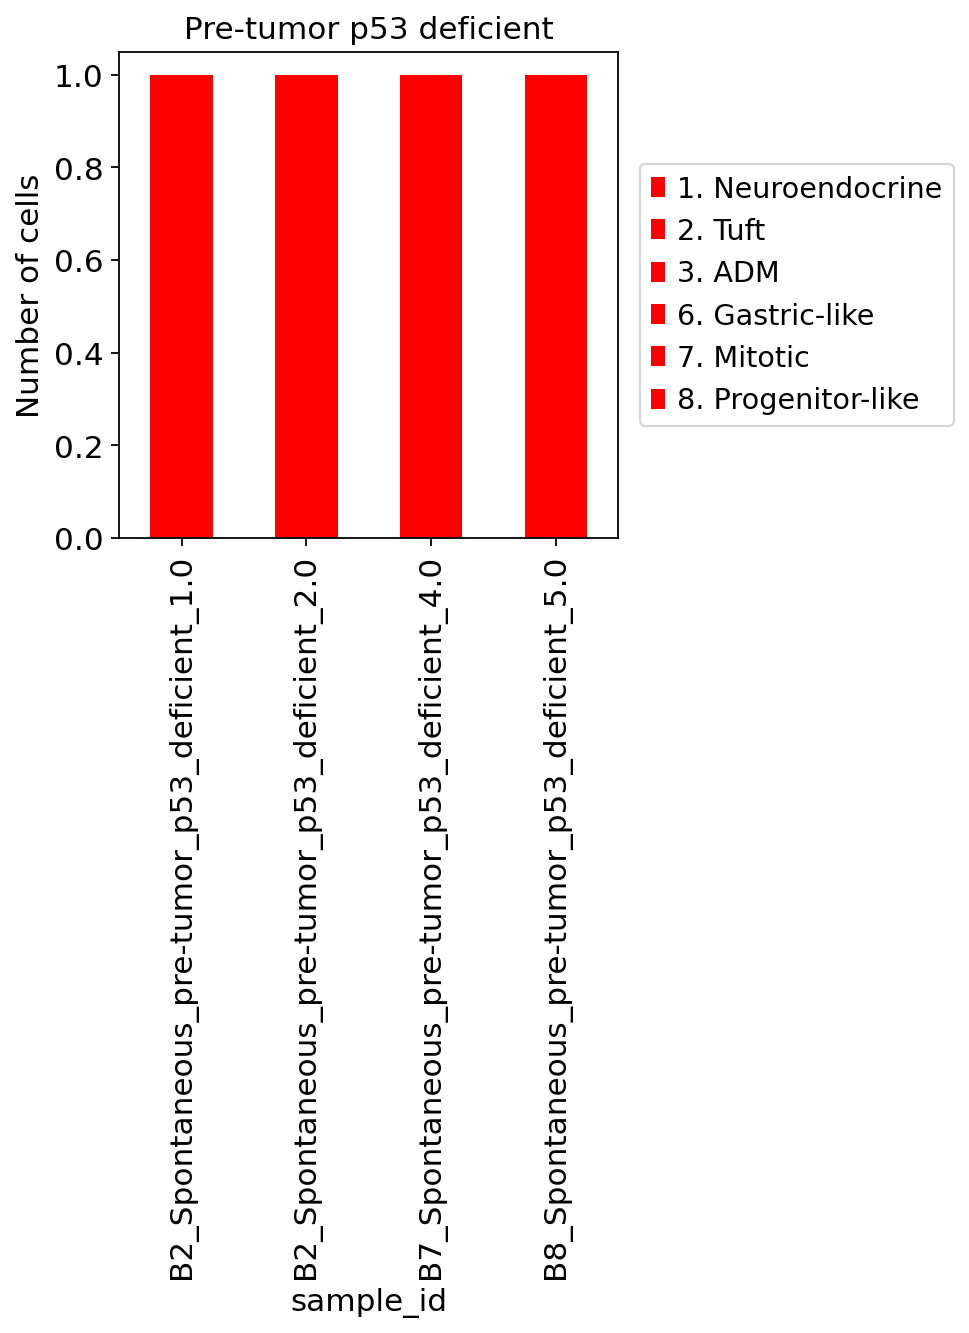

In [ ]:
adata.obs['sample_id'] = [re.sub('K\d.*?_', '', x) for x in adata.obs['replicate_id']]
adata.obs['sample_id'] = [re.sub('_[^_]*$', '', x) for x in adata.obs['sample_id']]

subcells = ismember(adata.obs['condition'], ['K4pretumorSP'])[1]
df = adata[subcells,:].obs[['cell_type', 'sample_id', 'unclear']].groupby(['sample_id', 'cell_type'], sort=True).size().unstack()
df = df.T / df.sum(axis=1)
df.T.plot(kind='bar', stacked=True, color = colors).legend(loc='right', bbox_to_anchor=[1,0,0.7,1])
plt.grid(False)
plt.ylabel('Number of cells')
plt.title('Pre-tumor p53 deficient')

if SAVE_FIGURES:
    df.to_csv(os.path.join(figure_path, 'Fig20260128_cellStateCount_perSample_pretumor_p53deficient_excludeMicrotumors.csv'))
    plt.savefig(os.path.join(figure_path, 'Fig20260128_cellStateCount_perSample_pretumor_p53deficient_excludeMicrotumors.pdf'))


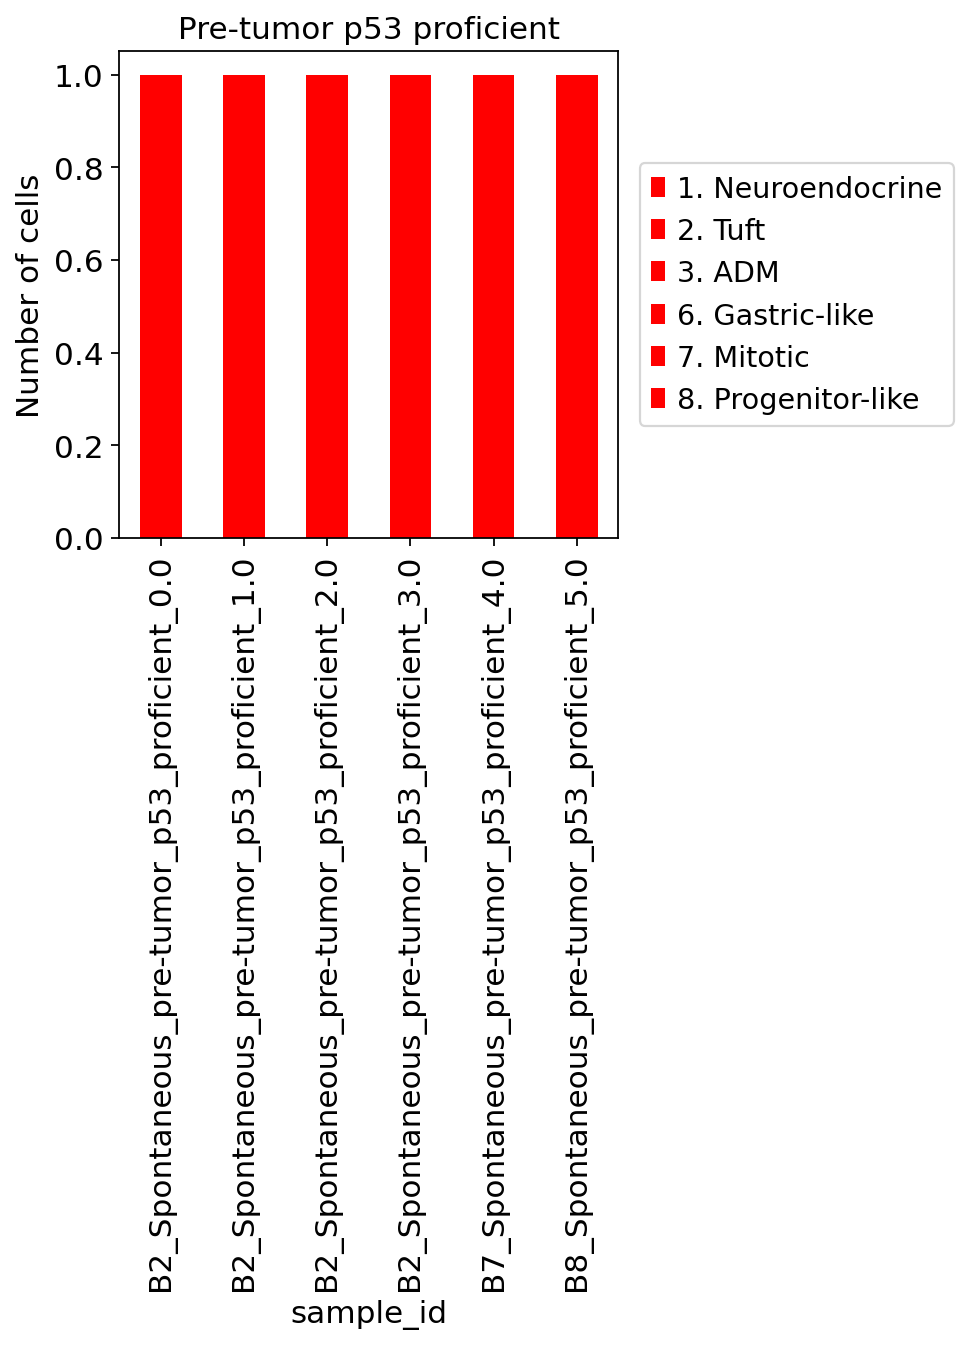

In [ ]:
subcells = ismember(adata.obs['condition'], ['K4pretumorDP'])[1]
df = adata[subcells,:].obs[['cell_type', 'sample_id', 'unclear']].groupby(['sample_id', 'cell_type'], sort=True).size().unstack()
df = df.T / df.sum(axis=1)
df.T.plot(kind='bar', stacked=True, color = colors).legend(loc='right', bbox_to_anchor=[1,0,0.7,1])
plt.grid(False)
plt.ylabel('Number of cells')
plt.title('Pre-tumor p53 proficient')

if SAVE_FIGURES:
    df.to_csv(os.path.join(figure_path, 'Fig20260128_cellStateCount_perSample_pretumor_p53proficient.csv'))
    plt.savefig(os.path.join(figure_path, 'Fig20260128_cellStateCount_perSample_pretumor_p53proficient.pdf'))


Save updated annotations

In [ ]:
if SAVE_FIGURES:
    annotation_filname = "../data/Reyes_KPLOH_SUBSET_pretumor_PDAC__annotated.csv"
    selected_obs = ['cell_type', 'cell_type_simple', 'tumor_cells', 'premalignant_like', 'tumor_samples', 'karyotype_simple', 'condition_simple']
    adata.obs[selected_obs].to_csv(annotation_filname)

In [ ]:
output_filename = "../data/Reyes_KPLOH_SUBSET_pretumor_PDAC__annotated.h5ad"
if not os.path.exists(output_filename):
    sc.write(output_filename, adata = adata)

### Plot marker genes for specific subpopulations

In [ ]:
adata_temp = adata.copy()
adata_temp.var_names = [x.capitalize() for x in adata_temp.var_names]
adata_temp = adata_temp[ismember(adata_temp.obs['cell_type_simple'], ['Gastric', 'ADM', 'Neu', 'Progenitor', 'Cycling', 'Tuft', 'Cancer'])[1],:].copy()

In [ ]:
cell_type = adata_temp.obs['cell_type'].to_numpy()
cell_type[cell_type == '6. Gastric-like'] = '6.0 Gastric-like'
cell_type[np.logical_and(cell_type == '6.0 Gastric-like', adata_temp.obs['pheno_30'] == 1)] = '6.2 Gastric-chief'
cell_type[np.logical_and(cell_type == '6.0 Gastric-like', adata_temp.obs['pheno_30'] == 12)] = '6.1 Gastric-pit'
adata_temp.obs['cell_type'] = cell_type.copy()

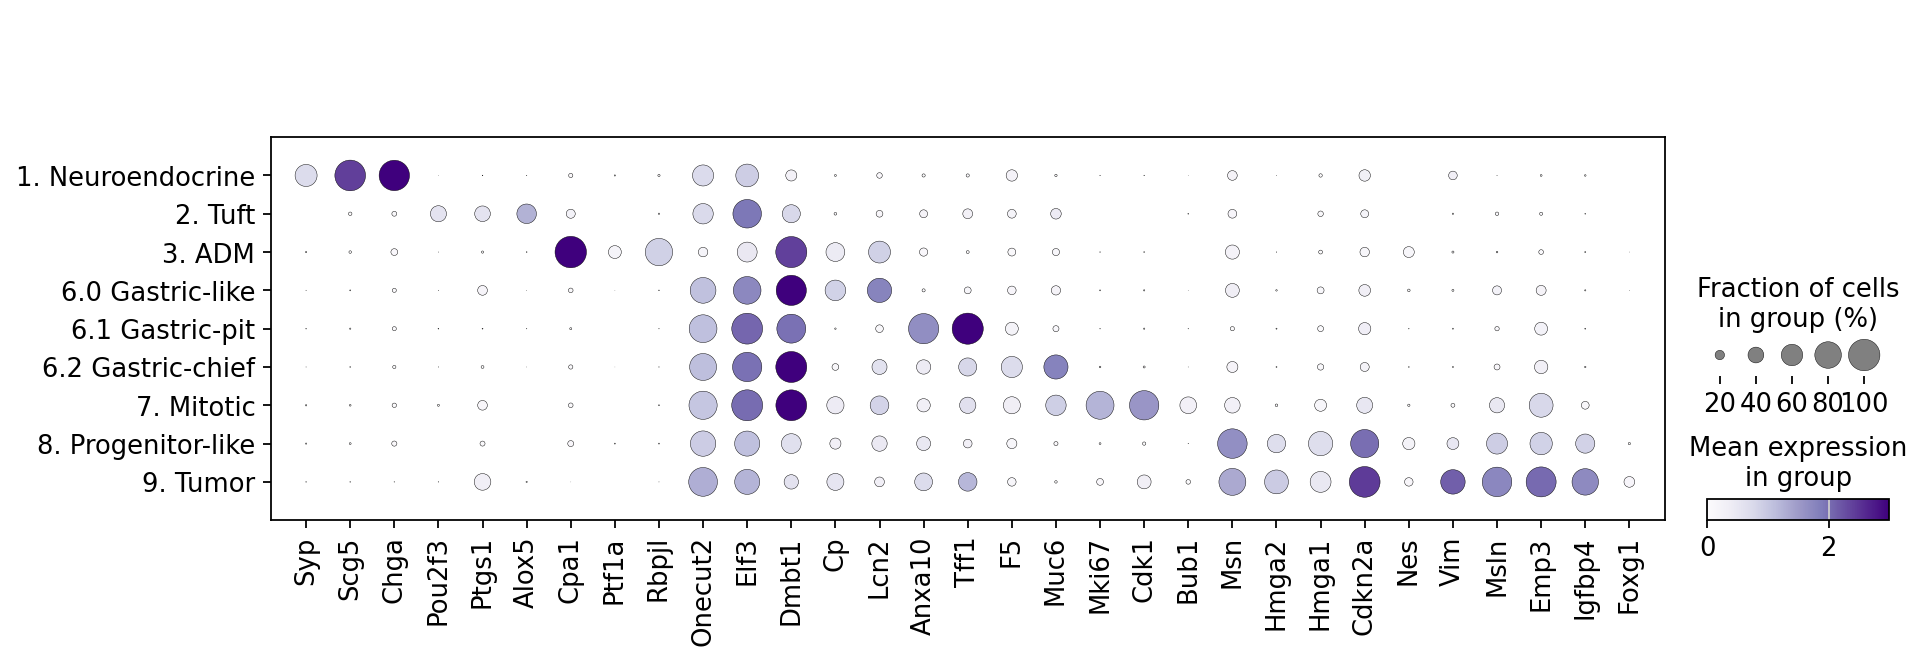

In [ ]:
figure_name = "Figure20251220_marker_genes_KPLOH_REVISIONS.pdf"
selected_genes = ['Syp', 'Scg5', 'Chga', 'Pou2f3', 'Ptgs1', 'Alox5', 'Cpa1', 'Ptf1a', 'Rbpjl', 'Onecut2', 'Elf3', 'Dmbt1', 'Cp', 'Lcn2', 'Anxa10', 'Tff1', 'F5', 'Muc6', 'Mki67', 'Cdk1', 'Bub1', 'Msn', 'Hmga2', 'Hmga1', 'Cdkn2a', 'Nes', 'Vim', 'Msln', 'Emp3', 'Igfbp4', 'Foxg1']
if SAVE_FIGURES:
    sc.pl.dotplot(adata_temp, groupby='cell_type', var_names = selected_genes, cmap = 'Purples', vmax = 3, save=figure_name)
else:
    sc.pl.dotplot(adata_temp, groupby='cell_type', var_names = selected_genes, cmap = 'Purples', vmax = 3)


### Get CNV profiles of pretumor SP 2

Microtumor 2

In [ ]:
selected_replicates = [
    'B2_K4microtumorSP_Spontaneous_pre-tumor_p53_deficient_2.0_unhashed',
    'B2_K4pretumorSP_Spontaneous_pre-tumor_p53_deficient_2.0_unhashed'
]
adata_temp = adata_cnv[ismember(adata_cnv.obs['replicate_id'], selected_replicates)[1],:].copy()
adata_temp.obs['cell_type_simple'] = adata[adata_temp.obs_names,:].obs['cell_type_simple'].to_numpy()

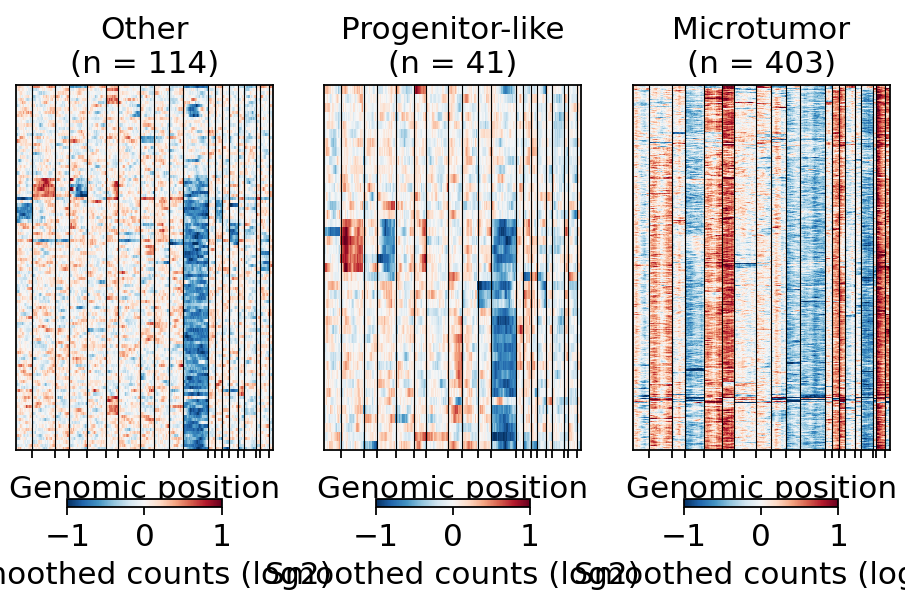

In [ ]:
f, ax = plt.subplots(1,3, figsize=[7,4])
subcells = np.logical_not(ismember(adata_temp.obs['cell_type_simple'], ['Cancer', 'Progenitor'])[1])
plot_CNV_matrix(adata_temp.obsm['smoothed_counts'], adata_temp.obs['prefix'], adata_temp.uns['newAnnotation']['chrNum'].to_numpy(), subcells, ax[0])
ax[0].set_title("Other\n(n = " + str(np.sum(subcells)) + ")")
subcells = ismember(adata_temp.obs['cell_type_simple'], ['Progenitor'])[1]
plot_CNV_matrix(adata_temp.obsm['smoothed_counts'], adata_temp.obs['prefix'], adata_temp.uns['newAnnotation']['chrNum'].to_numpy(), subcells, ax[1])
ax[1].set_title("Progenitor-like\n(n = " + str(np.sum(subcells)) + ")")
subcells = adata_temp.obs['cell_type_simple'] == 'Cancer'
plot_CNV_matrix(adata_temp.obsm['smoothed_counts'], adata_temp.obs['prefix'], adata_temp.uns['newAnnotation']['chrNum'].to_numpy(), subcells, ax[2])
ax[2].set_title("Microtumor\n(n = " + str(np.sum(subcells)) + ")")
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Figure20241214_pretumorSP_2_CNV_tracing.pdf'))

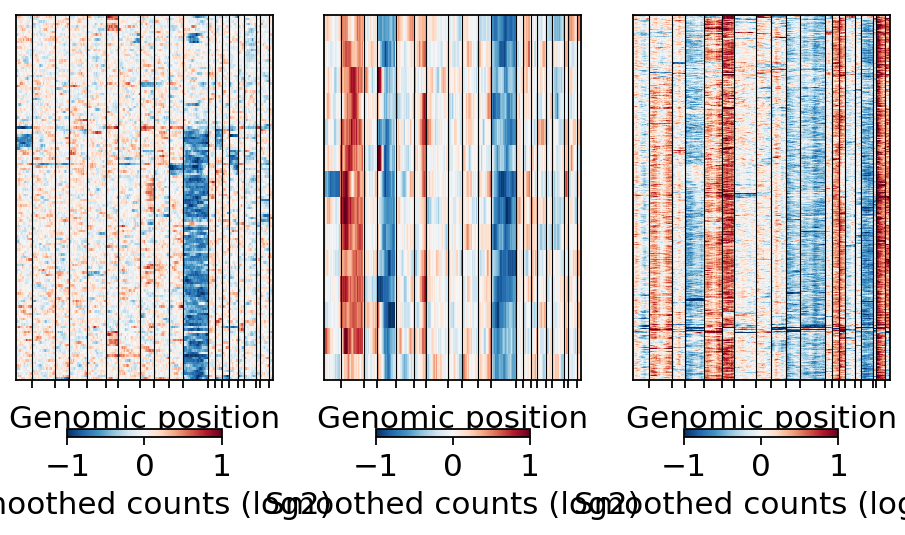

In [ ]:
chr2_gain = np.median(adata_temp.obsm['smoothed_counts'][:,adata_temp.uns['newAnnotation']['chrom'] == 'chr2'], axis=1) > 0.2
chr4_loss = np.median(adata_temp.obsm['smoothed_counts'][:,adata_temp.uns['newAnnotation']['chrom'] == 'chr4'], axis=1) < -0.2
chr11_loss = np.median(adata_temp.obsm['smoothed_counts'][:,adata_temp.uns['newAnnotation']['chrom'] == 'chr11'], axis=1) < -0.2

f, ax = plt.subplots(1,3, figsize=[7,4])

rearranged_cells = (chr2_gain) & (chr4_loss) & (chr11_loss)
rearranged_cells = np.logical_and(rearranged_cells, np.logical_not(adata_temp.obs['cell_type_simple'] == 'Cancer'))
other_cells = np.logical_and(np.logical_not(rearranged_cells), np.logical_not(adata_temp.obs['cell_type_simple'] == 'Cancer'))

plot_CNV_matrix(adata_temp.obsm['smoothed_counts'], adata_temp.obs['prefix'], adata_temp.uns['newAnnotation']['chrNum'].to_numpy(), other_cells, ax[0])
plot_CNV_matrix(adata_temp.obsm['smoothed_counts'], adata_temp.obs['prefix'], adata_temp.uns['newAnnotation']['chrNum'].to_numpy(), rearranged_cells, ax[1])
plot_CNV_matrix(adata_temp.obsm['smoothed_counts'], adata_temp.obs['prefix'], adata_temp.uns['newAnnotation']['chrNum'].to_numpy(), adata_temp.obs['cell_type_simple'] == 'Cancer', ax[2])

cell_type_karyotype = np.array(['other']*adata_temp.n_obs, dtype=object)
cell_type_karyotype[rearranged_cells] = 'precursor'
cell_type_karyotype[adata_temp.obs['cell_type_simple'] == 'Cancer'] = 'cancer'

adata_temp.obs['cell_type_karyotype'] = cell_type_karyotype.copy()

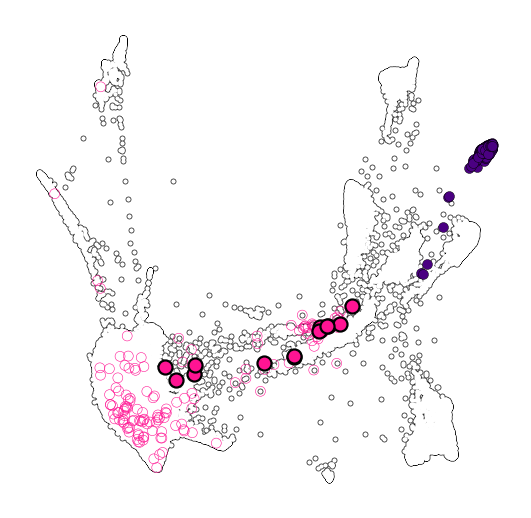

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black', rasterized=True)
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white', rasterized=True)

x = adata[adata_temp.obs_names,:].obsm['X_draw_graph_fa'][:,0]
y = adata[adata_temp.obs_names,:].obsm['X_draw_graph_fa'][:,1]

subcells = cell_type_karyotype == 'cancer'
my_scatter = plt.scatter(x[subcells], y[subcells], s=20, edgecolor='black', color='indigo', linewidth=0.2)
subcells = cell_type_karyotype == 'other'
my_scatter = plt.scatter(x[subcells], y[subcells], s=20, edgecolor='deeppink', color='None', linewidth=0.25)
subcells = cell_type_karyotype == 'precursor'
my_scatter = plt.scatter(x[subcells], y[subcells], s=40, edgecolor='black', color='deeppink', linewidth=1)

plt.grid(False)
plt.axis(False)

if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Figure20241214_pretumorSP_2_CNV_tracing_FDL.pdf'))

### Calculate diffusion distance to closest cancer cell

In [ ]:
suffix = "allTumors"
DC_knn = adata.uns['DC_knn']
display(DC_knn)

In [ ]:
plt.plot(adata.uns["diff_comp_eigenvalues"][0:40], 'p', c='black')
plt.xlabel('Diffusion component')
plt.ylabel('Eigenvalue')
plt.title('Spontaneous tumorigenesis\nAll cells')
plt.grid(False)

nDCs = 15
plt.plot([nDCs+0.5, nDCs+0.5], plt.gca().get_ylim(), c='red')

df = pd.DataFrame({'Eigenvalue_rank': list(range(40)), 'diff_component_eigenvalues': adata.uns["diff_comp_eigenvalues"][0:40]})
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20231106_diffComponents_k%d_%s.pdf' % (DC_knn, suffix)))
    df.to_csv(os.path.join(figure_path, 'Fig20231106_diffComponents_k%d_%s.csv' % (DC_knn, suffix)))

In [ ]:
adata.obsm['X_diff_comp'] = np.array(adata.obsm['X_diff_comp'])[:,0:(nDCs+1)]
adata.uns['diff_comp_eigenvalues'] = np.array(adata.uns['diff_comp_eigenvalues'])[0:(nDCs+1)]

In [ ]:
import numba
query_cells = np.where(ismember(adata.obs['condition'], ['K4pretumorDP'])[1])[0]
query_cells = np.where(adata.obs['premalignant_like'] == True)[0]
target_cells = np.where(adata.obs['tumor_cells'] == True)[0]

closest_target_cell = np.array([np.nan] * adata.n_obs)
closest_target_distance = np.array([np.nan] * adata.n_obs)

t = 3
eigenvalues = np.power(adata.uns['diff_comp_eigenvalues'], 2*t)
target_DC_profiles = adata.obsm['X_diff_comp'][target_cells,:]
for row in numba.prange(len(query_cells)):
    query_DC_profile =adata.obsm['X_diff_comp'][query_cells[row],:][:,None].T
    dists = np.sum(np.multiply(np.power(np.subtract(target_DC_profiles, query_DC_profile), 2), eigenvalues), axis=1)
    min_dist = np.where(dists == np.min(dists))[0][0]
    closest_target_cell[query_cells[row]] = target_cells[min_dist]
    closest_target_distance[query_cells[row]] = dists[min_dist]

adata.obs['closest_tumor_cell'] = closest_target_cell
adata.obs['closest_tumor_distance'] = np.log(closest_target_distance)/np.log(2)

Plot diffusion distance as a function of cell state in pretumor p53 proficient cells

In [ ]:
colors = ['gold', 'lightskyblue', 'limegreen', 'navy', 'mediumorchid', 'red']

In [ ]:
subcells = ismember(adata.obs['condition'], ['K4pretumorDP'])[1]
df = adata.obs[['closest_tumor_distance', 'cell_type']]
df['included'] = subcells
f,ax = plt.subplots(1,1, figsize=[2.5,3])

flierprops = dict(markerfacecolor='red', markeredgecolor='none', markersize=2, marker='o', linestyle='none')
h = sns.boxplot(x='cell_type', y='closest_tumor_distance', data=df.loc[subcells,:], flierprops=flierprops, ax=ax, order=np.sort(np.unique(adata.obs['cell_type'][subcells])), palette = colors, linewidth=0.25, saturation=1)
for i in range(len(colors)):
    h.get_children()[i*6 + 6 + i].set_markerfacecolor(colors[i])
    #h.get_children()[i*6 + 6 + i].set_markeredgecolor('black')
plt.ylabel('log2(diffusion distance\nto closest cancer cell)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.xlabel('')
plt.grid(False)
plt.ylim([-24,-4])

SAVE_FIGURES = True
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, 'Fig20260128_pretumorDP_diffDistance_to_cancer_preDP_nDC_0_16.pdf'))
    df.to_csv(os.path.join(figure_path, 'Fig20260128_pretumorDP_diffDistance_to_cancer_preDP_nDC_0_16.csv'))


### Analyze signatures in progenitor-like vs other premalignant and cancer

Visualize p53 signature in force directed layout

In [ ]:
selected_genes = ['Mdm2', 'Cdkn1a', 'Bax', 'Bbc3', 'Zmat3', 'Mgmt', 'Ccng1', 'Eda2r', 'Perp', 'Pmaip1', 'Psrc1']
adata_sub.obs['p53_activity'] = np.ravel(adata_sub.layers['zscore'][:,ismember(adata_sub.var_names, selected_genes)[1]].mean(axis=1))
grayout_cells = []
plot_signature(adata_sub, "X_draw_graph_fa", "p53_activity", exclude_cells = [], grayout_cells = grayout_cells, figsize=[5,5], s=1, grayout_color='white', vmin=-3, vmax=3, cmap='RdBu_r')
if SAVE_FIGURES:
    plt.savefig(os.path.join(figure_path, "Figure20231117_p53_activity_RdBu.pdf"))

p53 signatures in p53 proficient and deficient cells

In [ ]:
karyotype_filter = ismember(adata.obs['karyotype_class'], ['1_pre_dp_diploid', '2_pre_dp_chr6_gain', '3_pre_sp_quiet', '5_pre_sp_noChr11Loss'])[1]
condition_filter = ismember(adata.obs['condition'], ['K4pretumorDP', 'K4pretumorSP'])[1]
adata.obs['progenitor'] = [x if x == 'Progenitor' else 'Other' for x in adata.obs['cell_type_simple']]

selected_genes = ['Mdm2', 'Cdkn1a', 'Bax', 'Bbc3', 'Zmat3', 'Mgmt', 'Ccng1', 'Eda2r', 'Perp', 'Pmaip1', 'Psrc1', 'Nes', 'Msn', 'Hmga2', 'Hmga1', 'Itgb4', 'Itga3', 'Lama3', 'Lamb3']
adata_sub = adata.copy()
adata_sub.var_names = [x.capitalize() for x in adata_sub.var_names]

subcells = np.logical_and(condition_filter, karyotype_filter)

adata_temp = adata_sub[subcells,:].copy()
annotate_groups(adata_temp, ['cell_type', 'condition'])

filename = 'Figure20231117_KPLOH_p53_targets_per_cell_type.pdf'
if SAVE_FIGURES:
    sc.pl.matrixplot(adata_temp, groupby='group_id', var_names=selected_genes, layer='zscore', cmap='RdBu_r', vmin=-3, vmax=3, save=filename)
    mp = sc.pl.MatrixPlot(adata_temp, groupby='group_id', var_names=selected_genes, layer='zscore', cmap='RdBu_r', vmin=-3, vmax=3)
    mp.values_df.to_csv(os.path.join(figure_path, re.sub('.pdf', '.csv', filename)))
else:
    sc.pl.matrixplot(adata_temp, groupby='group_id', var_names=selected_genes, layer='zscore', cmap='RdBu_r', vmin=-3, vmax=3)

In [ ]:
adata_sub.obs['sample_id'] = [re.sub('_[^_]*$', '', x) for x in adata_sub.obs['replicate_id']]

subcells = condition_filter.copy()
subcells = np.logical_and(subcells, ismember(adata.obs['cell_type'], ['8. Progenitor-like'])[1])
subcells = np.logical_and(subcells, karyotype_filter)

adata_temp = adata_sub[subcells,:].copy()
annotate_groups(adata_temp, ['condition', 'sample_id'])

filename = 'Figure20231117_KPLOH_Progenitor_SP_vs_DP_p53_targets.pdf'

if SAVE_FIGURES:
    sc.pl.matrixplot(adata_temp, groupby='group_id', var_names=selected_genes, layer='zscore', cmap='RdBu_r', vmin=-3, vmax=3, save=filename)
    mp = sc.pl.MatrixPlot(adata_temp, groupby='group_id', var_names=selected_genes, layer='zscore', cmap='RdBu_r', vmin=-3, vmax=3)
    mp.values_df.to_csv(os.path.join(figure_path, re.sub('.pdf', '.csv', filename)))
else:
    sc.pl.matrixplot(adata_temp, groupby='group_id', var_names=selected_genes, layer='zscore', cmap='RdBu_r', vmin=-3, vmax=3)

Oncogenic and tumor suppressive signatures

In [ ]:
selected_signatures = [
    'p53_canonical',
    'FisherOncogeneTable2_processed',
    'BiegingRolett_p53_TSAG_bound',
    'SENESCENCE_INTERNAL_PDAC_p53_restoration_UpSet_UP_Top',
    'cdkn2a_canonical',
    'David_Smad4_dependent_tgfb_response',
    'TASDEMIR_Senescence_UP',
    'LOH_single_cell_pseudobulk_UP_in_PDAC',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'Vallejo_KRAS_8genes',
    'DAC_Kras_vs_ADM_UP_T3_vs_T2',
    'Glycolysis_Warburg',
]

In [ ]:
adata.obs['progenitor'] = ['progenitor' if x == '8. Progenitor-like' else 'other' for x in adata.obs['cell_type']]
condition_filter = ismember(adata.obs['condition_simple'], ['K4pretumorDP', 'K5tumorSP'])[1]
adata_sub = adata[condition_filter,:].copy()
sc.pl.matrixplot(
    adata_sub, groupby = ['condition_simple', 'progenitor'], 
    var_names = selected_signatures, vmin = -1.5, vmax = 1.5, 
    cmap = 'RdBu_r', swap_axes = True, save = 'Fig20250428_progenitor_cancer_signatures.pdf')

Plot signature distributions

In [ ]:
cell_type_filter = adata_sub.obs['cell_type'] != '9. Tumor_premalignant_like'
adata_temp = adata_sub[cell_type_filter,:].copy()
excluded_conditions = ['K4pretumorSP', 'K4microtumorSP', 'K5ctrl', 'K5tumorSP', 'K6ctrl']
adata_temp = adata_temp[np.logical_not(ismember(adata_temp.obs['condition'], excluded_conditions)[1]),:].copy()

simplified_dictionary = {
    '1. Neuroendocrine': 'other', 
    '2. Tuft': 'other', 
    '3. ADM': 'other', 
    '6. Gastric-like': 'other',
    '7. Mitotic': 'other', 
    '8. Progenitor-like': 'progenitor', 
    '9. Tumor': 'cancer'
}

df = adata_temp.obs[selected_signatures]
df['cell_type'] = [simplified_dictionary[x] for x in adata_temp.obs['cell_type']]
type_counts = df['cell_type'].value_counts()
df['cell_type_verbose'] = [x + '\n(n=' + str(type_counts.loc[x]) + ')' for x in df['cell_type']]
df['location'] = [0 if x == 'other' else 1 for x in df['cell_type']]

In [ ]:
for my_signature in selected_signatures:
    plt.figure(figsize = [2.5,2])
    sns.violinplot(
        x = 'location', y = my_signature, hue = 'cell_type_verbose', 
        data = df, saturation = 1, palette = ['navy', 'red'],
        width = 1, gap = 0.5
    )
    stat_result = scipy.stats.ranksums(df[my_signature][df['cell_type'] == 'progenitor'], df[my_signature][df['cell_type'] == 'other'])
    plt.text(0,0,s = 'p-value = ' + str(stat_result.pvalue))

    #plt.ylim([-1,3])
    plt.xlim([-0.75,1.75])

    plt.legend(frameon=False, loc = 'upper left')
    plt.grid(False)
    plt.savefig(os.path.join(figure_path, "Figure20260128_signatureViolin_" + my_signature + ".pdf"))

#df.to_csv(os.path.join(figure_path, "Figure20250324_signatureViolin.csv"))